# EDIS 8100 · Week 9 · Collaboration Analytics Lab

### Reading a group by its chat, in two settings, and deciding what a dashboard should refuse to show

**Estimated time:** about 40 minutes for the core path, plus stretch goals if you want them.

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

---

Week 6 you met thirty-nine pairs of children solving a graph problem with a robot. Their record is waiting
for you again in Section 5. This week you point the same idea at a different room: eight groups of
undergraduates in a computer networks course, working together over a text chat across four days in
February 2021.

The two settings are here on purpose. A single dataset can only tell you what happened in it. Two datasets
let you ask the question that matters for anything you would build: **does the finding travel?**

A third thing is going on here. These are real logs, exported by a real platform, and the platform wrote
its timestamps to the nearest minute. That one engineering decision, made years before anyone thought
about analytics, quietly decides which of this week's measures can exist at all. Section 2 is about that.

## Learning objectives

By the end of this notebook you will be able to:

1. Open a real, messy export, name each cleaning decision out loud, and say what the decision costs.
2. Recognise when a measure is reporting the **instrument's resolution** rather than the behaviour, and
   retire the measure rather than reporting it.
3. Compute the unevenness of recorded participation for a group, read it against both its ceiling and
   against what chance alone would produce, and describe the spread across groups without over-testing it.
4. Say precisely why eight groups, two sittings each, will not support a group-level significance claim,
   and what nesting does to any interval you might be tempted to print.
5. Argue, with evidence from these two datasets, what a collaboration dashboard should refuse to
   display, and to whom.

## How this notebook works (read this if you are new to code)

- Run the cells in order, top to bottom. Click a cell and press **Shift + Enter**.
- Nothing here can break your computer, your Google account, or the course data. The worst case is an
  error message, which is information about what the code did.
- If a cell errors and you cannot see why, the fix is almost always to start over from the top:
  **Runtime > Restart and run all** in Colab, or **Kernel > Restart & Run All** in Jupyter.
- The core path runs untouched. The cells marked **Your turn** already contain working values, so
  the notebook runs end to end even if you change nothing. Change them anyway once you are comfortable.
- You are not expected to write code from scratch today. You are expected to read output carefully and
  argue about what it means, which is the doctoral level skill here.
- The data download from the internet. If your connection drops, the first cell will say so in plain
  English and tell you where the files live.

Section markers: objectives · setup · cleaning · time · analysis · chance and uncertainty · does it travel
· your turn · discuss · submit

## How to work through this notebook

**Every code cell here runs as written.** You can press Shift and Enter from the top of this notebook to the bottom without editing anything, and nothing will break and nothing will be missing. That is tested before the notebook is published: a clean machine with no data on it runs the whole file end to end.

**The cells marked Your turn already hold a working value.** Changing it and re-running shows you what that choice was doing to the result, which is the point of marking it. If you never touch one, you still get every finding this notebook is about. Nothing is missing from a run you did not edit.

**What is graded is what you write in the interpretation cells:** what the method can see, what it cannot, and what you would refuse to conclude from it. A person who runs every cell as written and writes a sharp reading of the output has done the assignment. A person who rewrites the code and writes three vague sentences has not.

**If you work in R, SPSS, or Stata, or have not written code before,** that is the expected starting point here. Read the code the way you read a methods section: you are checking what was done to the data, not memorizing syntax. Two patterns cover most of it. Square brackets after a table, as in `df[df.score > 50]`, are subsetting, the same idea as `subset()` or a filter. A line ending in `.mean()`, `.sum()`, or `.value_counts()` is an aggregation, the same idea as `aggregate()` or a frequency table. When a line will not decode, ask in class rather than working around it.


## Setup

There are two published datasets here. Neither was collected by this course, neither was collected for it,
and both are redistributed under the licence their authors chose. Read this before you run anything,
because half of the analytic judgment this week comes from knowing who was in the room.

### Dataset 1: eight groups in a computer networks course

`collab-chat/chat_logs.csv`, 1,374 messages by 4 columns.

- **Who collected it.** Cristina Villa-Torrano, Universidad de Valladolid, from undergraduates in two
  computer networks courses working through Moodle and an online platform called CoTrackV2. The full
  release also contains document logs, Moodle logs, submissions and questionnaires; the course extract
  keeps the chat log only.
- **Who is in it.** Eight groups of four or five students, working over four days in February 2021,
  online, in Spanish, during the second pandemic academic year.
- **Licence.** Creative Commons Attribution 4.0 International (CC BY 4.0). Free to share and adapt with
  attribution.
- **Citation.** Villa-Torrano, C. (2021). *Dataset on an online collaborative learning situation in a
  computer networks course* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.5150537

### Dataset 2: the children from Week 6

`justhink/per_participant.csv` and `justhink/pehri_team_outcomes.csv`.

- **Who collected it.** Utku Norman, Jauwairia Nasir, Barbara Bruno, Pierre Dillenbourg and colleagues at
  EPFL, from the JUSThink activity, in which pairs of children build a minimum spanning tree together with
  a robot in the room.
- **Who is in it.** 78 children aged 9 to 12, in 39 teams of two. Speech was transcribed for a subset.
  Team level outcomes exist for 34 of the teams.
- **Licence.** Creative Commons Attribution 4.0 International (CC BY 4.0), both records.
- **Citations.**
  Norman, U., Dinkar, T., Nasir, J., Bruno, B., Clavel, C., & Dillenbourg, P. (2021). *JUSThink dialogue
  and actions corpus* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.4627104
  Nasir, J., Norman, U., Bruno, B., Chetouani, M., & Dillenbourg, P. (2021). *PE-HRI: A multimodal dataset
  for the study of productive engagement in a robot mediated collaborative educational setting*
  [Data set]. Zenodo. https://doi.org/10.5281/zenodo.4633092

### What neither dataset contains

Neither dataset records names. The chat data records no ages, and neither record has gender, language
background, prior attainment, or course grade. The chat data holds no measure at all of what any group
produced. There is no roster: the only people we can see are the people who typed. Every one of those
absences will constrain something later, and each time it does, the notebook will say so rather than
working around it quietly.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

BASE = "https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main"

# A colourblind safe palette (Okabe and Ito). Every figure in this notebook draws from it.
OKABE = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73", "red": "#D55E00",
         "purple": "#CC79A7", "sky": "#56B4E9", "yellow": "#F0E442", "grey": "#666666"}
MEMBER_COLORS = [OKABE["blue"], OKABE["orange"], OKABE["green"], OKABE["purple"], OKABE["sky"]]

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)


def load_course_csv(path, **kwargs):
    """Read one course CSV from GitHub, or explain the failure in plain English."""
    try:
        return pd.read_csv(f"{BASE}/{path}", **kwargs)
    except Exception as err:
        print("Could not download:", path)
        print("  The course datasets live at github.com/HakeoungLee/edis8100-datasets")
        print("  Nothing is broken and nothing you did caused this. Check your internet")
        print("  connection, then run this cell again.")
        print("  (what went wrong, for the curious:", type(err).__name__, ")")
        return None


# Note the two arguments on the first line. Section 1 explains why both are necessary.
chat_raw  = load_course_csv("collab-chat/chat_logs.csv", sep=";", encoding="utf-8-sig")
children  = load_course_csv("justhink/per_participant.csv")
teams_out = load_course_csv("justhink/pehri_team_outcomes.csv")

if all(df is not None for df in (chat_raw, children, teams_out)):
    print("All three files loaded. You are ready to go.")
    print()
    print(f"  chat_logs.csv            {chat_raw.shape[0]:>5} rows x {chat_raw.shape[1]} cols"
          "    one row per chat message")
    print(f"  per_participant.csv      {children.shape[0]:>5} rows x {children.shape[1]} cols"
          "   one row per child")
    print(f"  pehri_team_outcomes.csv  {teams_out.shape[0]:>5} rows x {teams_out.shape[1]} cols"
          "    one row per team")
else:
    print("Something did not load. Read the message above, then run this cell again.")

All three files loaded. You are ready to go.

  chat_logs.csv             1374 rows x 4 cols    one row per chat message
  per_participant.csv         78 rows x 12 cols   one row per child
  pehri_team_outcomes.csv     34 rows x 6 cols    one row per team


---

## Section 1. The file as it arrived

Synthetic data arrives clean because somebody wrote it to be clean. Real exports arrive as whatever the
platform happened to write, and the first twenty minutes of any real analysis are spent finding out what
that was. **Every cleaning decision is a claim about the data, and each one narrows what you are later
allowed to say.**

The file will catch you out in ordinary ways:

1. It is **semicolon delimited**, not comma delimited. A default `pd.read_csv` returns one column
   containing the whole line.
2. It begins with a **byte order mark**, three invisible bytes (`EF BB BF`) that some Windows tools write
   at the top of a text file. Recent pandas quietly strips it when the encoding is UTF-8, so this one can
   hide until the day it does not. It surfaces the moment somebody reaches for `encoding="latin-1"`,
   which is the reflex when a file is full of accented Spanish: then the first column arrives named
   `ï»¿timestamp` and every accented character in the corpus turns to mojibake.
   `encoding="utf-8-sig"` names what the file actually is and costs nothing.
3. Its timestamps are **day first**, `15/02/2021`, in the European convention. Let pandas guess and it
   may silently read the fifteenth of February as the second of March.

The next cell shows each of those going wrong, on purpose, before showing it going right.

In [2]:
print("WHAT A DEFAULT read_csv WOULD HAVE DONE")
print("=" * 74)
wrong = pd.read_csv(f"{BASE}/collab-chat/chat_logs.csv", nrows=3)
print("  columns found with the default comma separator:", list(wrong.columns))
print("  ->", wrong.shape[1], "column, not 4. The file is semicolon delimited.")
print()
print("  now the same file read with encoding='latin-1', the usual guess for a file full of accents:")
latin = pd.read_csv(f"{BASE}/collab-chat/chat_logs.csv", sep=";", encoding="latin-1")
print("    first column name:", repr(latin.columns[0]))
print("    the bytes hiding in front of it:", latin.columns[0][:3].encode("latin-1"))
print("    -> EF BB BF is a byte order mark. chat['timestamp'] would raise a KeyError here.")
bad_rows = latin.index[latin["message"].str.contains(r"[^\x00-\x7F]", regex=True)]
i = int(bad_rows[0])
print(f"    and {len(bad_rows)} messages carry accents, which arrive mangled:")
print("      latin-1   :", latin.message.iloc[i])
print("      utf-8-sig :", chat_raw.message.iloc[i])
print()

print("THE TIMESTAMP COLUMN")
print("=" * 74)
print("  raw values look like:", chat_raw.timestamp.iloc[0], "and", chat_raw.timestamp.iloc[-1])
try:
    pd.to_datetime(chat_raw.timestamp.head(20), format="%m/%d/%Y %H:%M")
    print("  month-first parsing SUCCEEDED, which would be the dangerous outcome")
except ValueError:
    print("  month-first parsing raises ValueError, because there is no month 15.")
print("  -> we state day-first in the code rather than letting pandas infer it.")

chat = chat_raw.copy()
chat["ts"] = pd.to_datetime(chat["timestamp"], format="%d/%m/%Y %H:%M")
chat["day"] = chat["ts"].dt.date
chat["session"] = chat["Group"].astype(str) + " / " + chat["day"].astype(str)
chat = chat.sort_values(["Group", "ts"]).reset_index(drop=True)

print()
print("WHAT IS IN THE FILE, AND WHAT IS NOT")
print("=" * 74)
print("  messages           ", len(chat))
print("  missing values     ", int(chat[["timestamp", "authorid", "Group", "message"]].isna().sum().sum()))
print("  groups             ", chat["Group"].nunique(), "->", sorted(chat["Group"].unique()))
print("  distinct authorids ", chat["authorid"].nunique())
print("  authors per group  ", chat.groupby("Group")["authorid"].nunique().to_dict())
print("  authors writing in more than one group:",
      int((chat.groupby("authorid")["Group"].nunique() > 1).sum()))
print("  calendar days      ", chat["day"].nunique(), "->",
      [str(d) for d in sorted(chat["day"].unique())])
print("  days per group     ", chat.groupby("Group")["day"].nunique().to_dict())
print("  group-days (we will call these sessions):", chat["session"].nunique())
print()
print("  Columns that do NOT exist: no roster, no names, no age, no gender, no language background,")
print("  no grade, no rubric, no measure of what any group produced. Four columns is the whole file.")
print("  The message text is in Spanish.")

WHAT A DEFAULT read_csv WOULD HAVE DONE
  columns found with the default comma separator: ['timestamp;authorid;Group;message']
  -> 1 column, not 4. The file is semicolon delimited.

  now the same file read with encoding='latin-1', the usual guess for a file full of accents:
    first column name: 'ï»¿timestamp'
    the bytes hiding in front of it: b'\xef\xbb\xbf'
    -> EF BB BF is a byte order mark. chat['timestamp'] would raise a KeyError here.
    and 185 messages carry accents, which arrive mangled:
      latin-1   : Localizacion de las habitaciones y conmutador? que esp responde a las preguntas de la seÃ±al
      utf-8-sig : Localizacion de las habitaciones y conmutador? que esp responde a las preguntas de la señal

THE TIMESTAMP COLUMN
  raw values look like: 15/02/2021 17:16 and 18/02/2021 23:11
  month-first parsing raises ValueError, because there is no month 15.
  -> we state day-first in the code rather than letting pandas infer it.

WHAT IS IN THE FILE, AND WHAT IS NOT
  

### The decisions

Each decision below has a cost. Argue with any of them later.

| Decision | What it buys | What it costs |
|---|---|---|
| Read day first, semicolon delimited, `utf-8-sig` | 1,374 usable rows, correct dates | Nothing. This one is simply correct. |
| **A session is one group on one calendar day.** | 16 sessions, a unit between "message" and "group" | The file has no session marker. If a group met twice on one day, we have merged the two. |
| **The roster is whoever typed at least once across the four days.** | 4 or 5 members per group, which matches the published design | A student who never typed at all is invisible to us. We cannot count a zero we cannot see. |
| **We work from metadata, not content.** | Everyone in the seminar can do the analysis | The messages are in Spanish, and none of what people actually said enters any measure here. That is a large thing to give up in a week about collaboration. |

The third one deserves a moment. Week 6 could rebuild a full roster because a sensor table listed every
child in every session. Here there is no such table. Three member-sessions in this file involve somebody
who typed on one of their group's two days and not the other, and those we can fill in as zeros because
we know they exist. Anyone who typed nothing across all four days leaves no trace at all, and every
unevenness measure below is therefore **a lower bound**: the true spread can only be wider than what we
compute, never narrower.

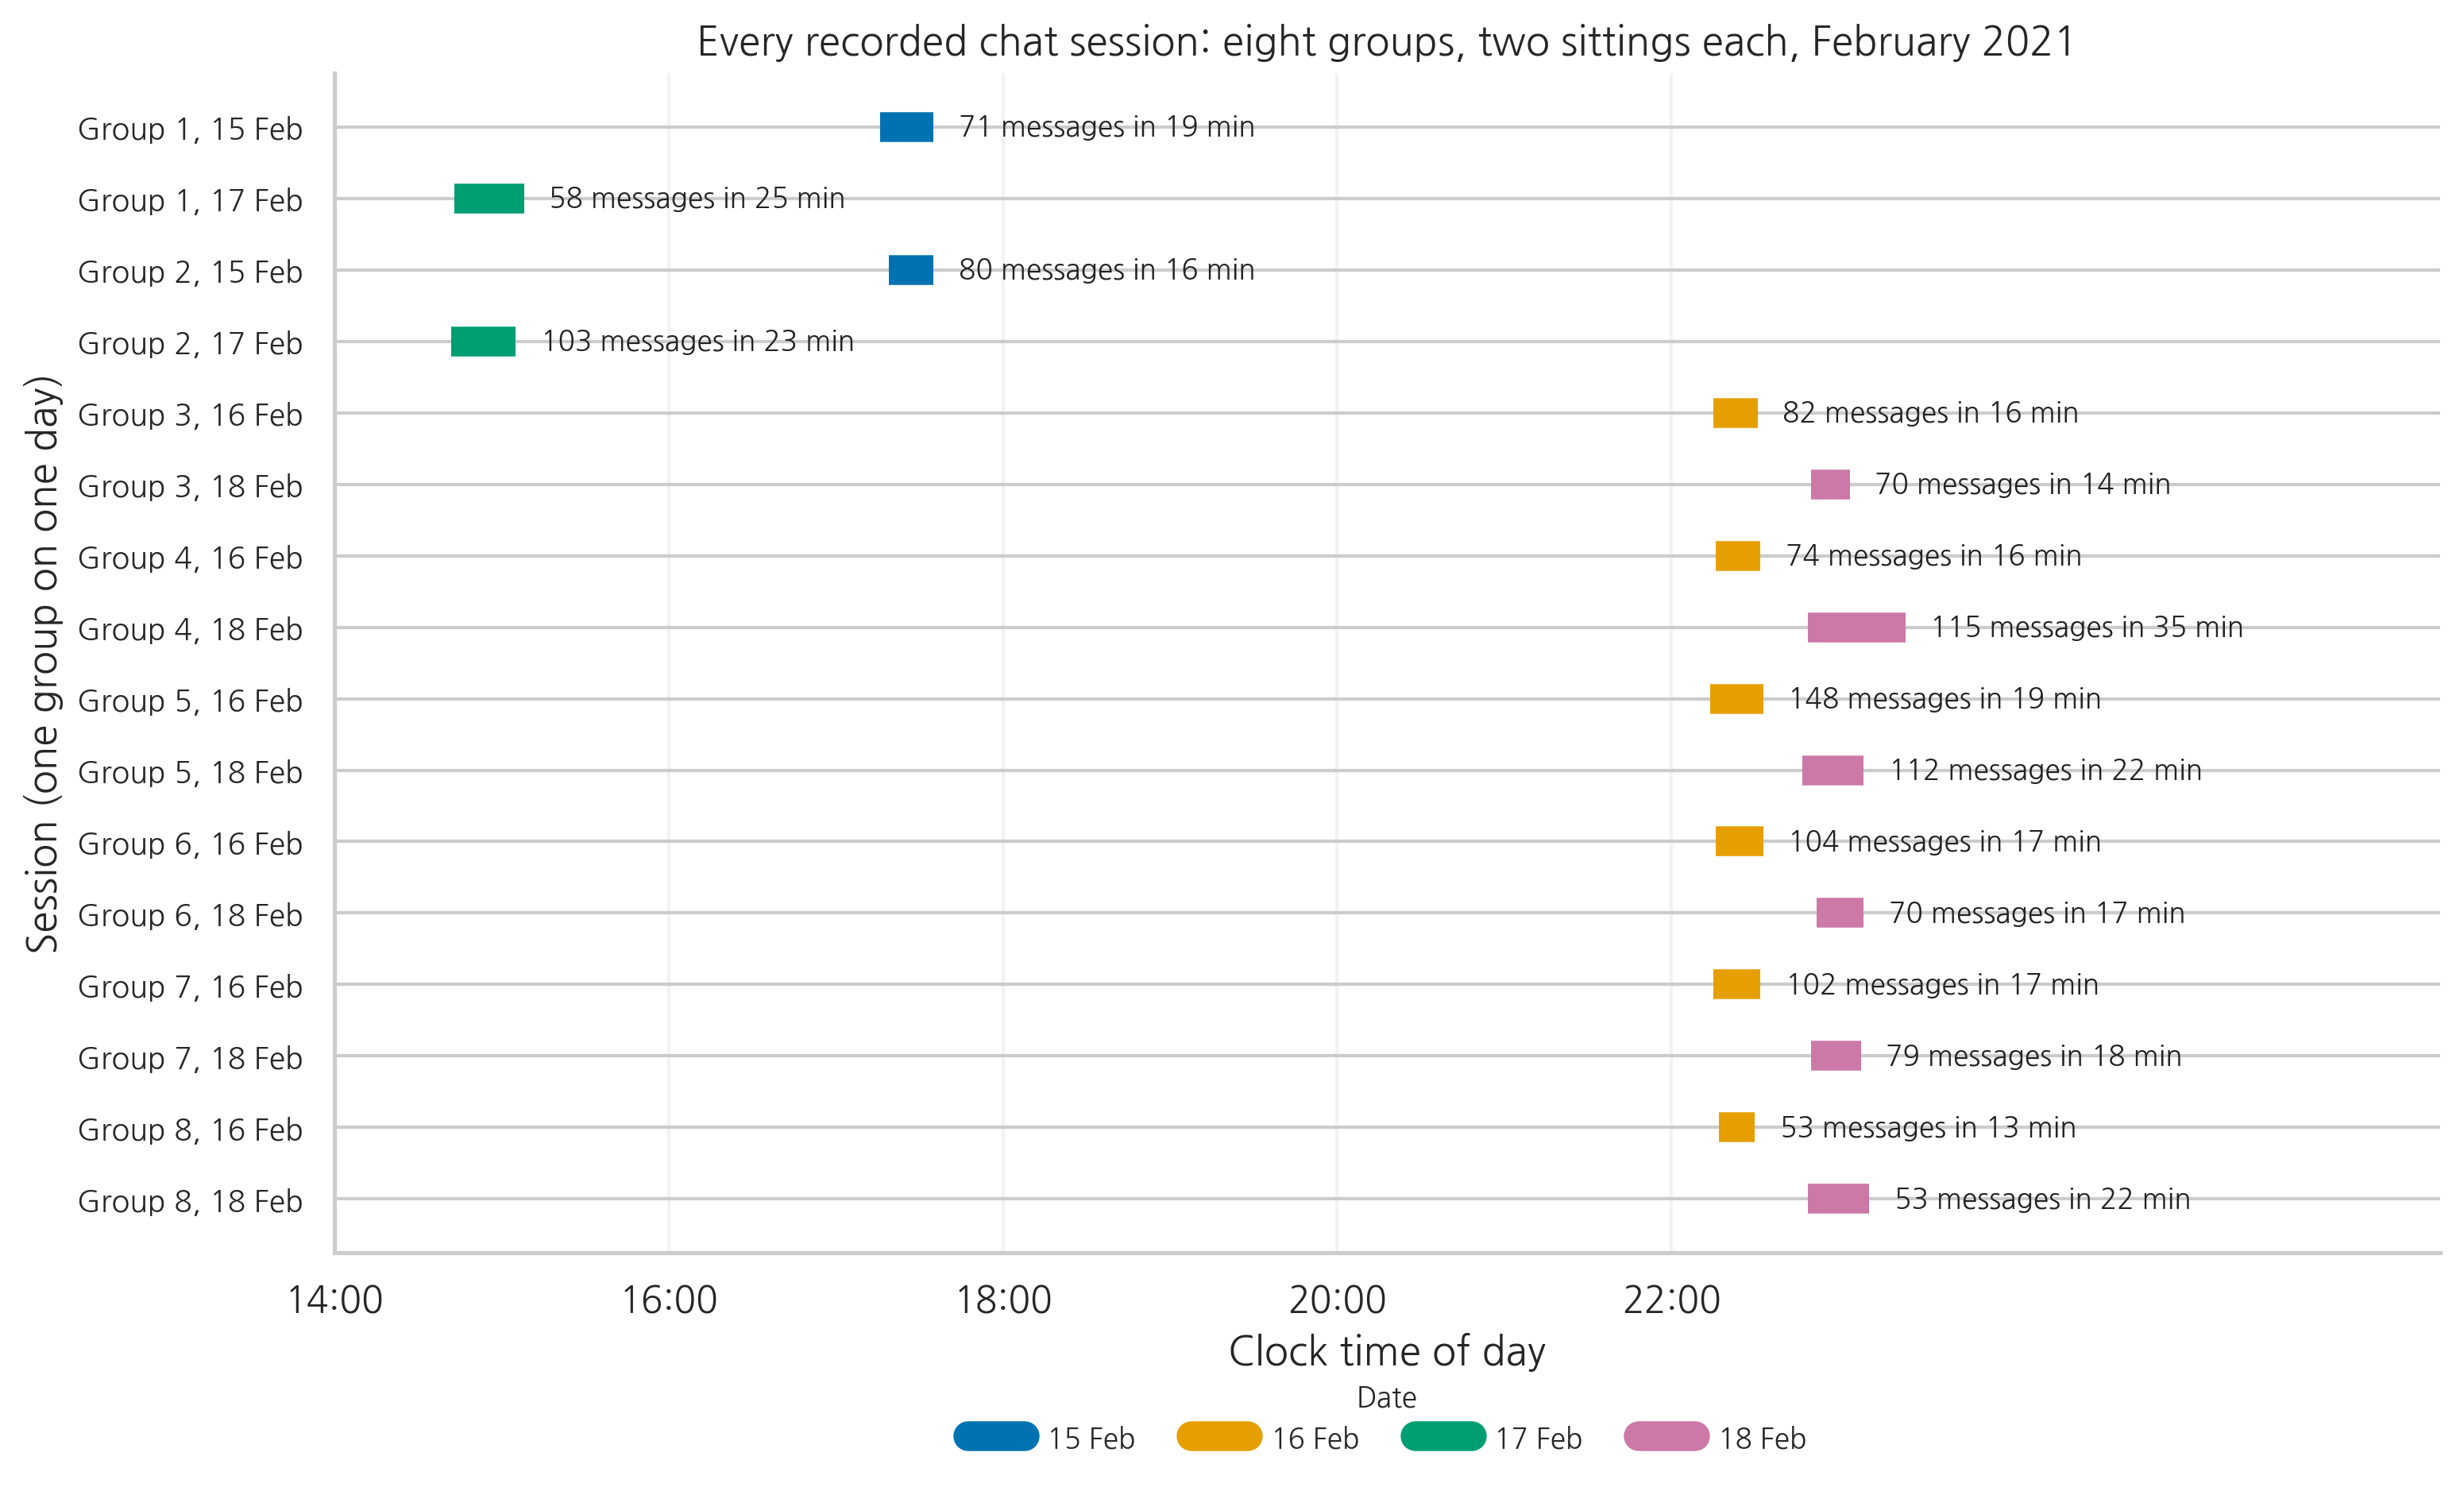

 Group        day  n_messages  span_min
     1 2021-02-15          71      19.0
     1 2021-02-17          58      25.0
     2 2021-02-15          80      16.0
     2 2021-02-17         103      23.0
     3 2021-02-16          82      16.0
     3 2021-02-18          70      14.0
     4 2021-02-16          74      16.0
     4 2021-02-18         115      35.0
     5 2021-02-16         148      19.0
     5 2021-02-18         112      22.0
     6 2021-02-16         104      17.0
     6 2021-02-18          70      17.0
     7 2021-02-16         102      17.0
     7 2021-02-18          79      18.0
     8 2021-02-16          53      13.0
     8 2021-02-18          53      22.0

session length: shortest 13 minutes, longest 35, median 17.5
messages per session: fewest 53, most 148, median 79.5


In [3]:
sessions = (chat.groupby(["Group", "day"])
                .agg(n_messages=("message", "size"), start=("ts", "min"), end=("ts", "max"))
                .reset_index())
sessions["span_min"] = (sessions["end"] - sessions["start"]).dt.total_seconds() / 60
sessions["start_h"] = sessions["start"].dt.hour + sessions["start"].dt.minute / 60
sessions["end_h"] = sessions["end"].dt.hour + sessions["end"].dt.minute / 60

DAY_COLORS = dict(zip(sorted(chat["day"].unique()),
                      [OKABE["blue"], OKABE["orange"], OKABE["green"], OKABE["purple"]]))

sessions = sessions.sort_values(["Group", "day"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10.5, 6.4))
for i, r in sessions.iterrows():
    ax.plot([r.start_h, r.end_h], [i, i], linewidth=9,
            color=DAY_COLORS[r.day], solid_capstyle="butt")
    ax.text(r.end_h + 0.15, i, f"{int(r.n_messages)} messages in {r.span_min:.0f} min",
            va="center", fontsize=8.5, color="#222222")
for d, c in DAY_COLORS.items():
    ax.plot([], [], linewidth=9, color=c, label=d.strftime("%d %b"))
ax.set_yticks(range(len(sessions)))
ax.set_yticklabels([f"Group {int(r.Group)}, {r.day:%d %b}" for _, r in sessions.iterrows()],
                   fontsize=9)
ax.invert_yaxis()
ax.set_xlim(14, 26.6)
ax.set_xticks(range(14, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(14, 24, 2)])
ax.set_xlabel("Clock time of day")
ax.set_ylabel("Session (one group on one day)")
ax.set_title("Every recorded chat session: eight groups, two sittings each, February 2021")
ax.legend(title="Date", loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=4,
          frameon=False, fontsize=8.5, title_fontsize=8.5)
ax.grid(axis="x", alpha=0.25)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

print(sessions[["Group", "day", "n_messages", "span_min"]].to_string(index=False))
print()
print(f"session length: shortest {sessions.span_min.min():.0f} minutes, "
      f"longest {sessions.span_min.max():.0f}, median {sessions.span_min.median():.1f}")
print(f"messages per session: fewest {sessions.n_messages.min()}, most {sessions.n_messages.max()}, "
      f"median {sessions.n_messages.median():.1f}")

**Interpret this chart before you scroll.**

- Groups 1 and 2 met in the afternoon on 15 and 17 February. Groups 3 to 8 met after ten at night on
  16 and 18 February. Nothing in the file says why. Before you invent a story about any group, write down
  what a course timetable, a lab rotation, or a shared deadline would each predict about that split.
- The sessions are short: the median is under twenty minutes, the longest is 35. A "collaboration
  analytics" dashboard built for semester-long teams would be describing something else entirely. What
  claims does a window that short let you make, and which ones does it quietly rule out?
- Group 5 sent 148 messages in 19 minutes and Group 8 sent 53 in 13. Both are real. Name one explanation
  in the **instrument** (what the chat could and could not capture while these students also had a shared
  document and possibly a voice call open), one in the **setting** (the task, the hour, the deadline), and
  one in the **circumstances** of a student's February 2021, before you reach for anything about the people.

### Your turn 1: read one session

Numbers about a conversation are easier to argue about once you have seen the conversation. The cell below
prints the opening exchange of one session, with each author relabelled `P1`, `P2` and so on **within that
session, ordered by how many messages they sent**. That relabelling is itself a decision: `P1` is always
the member with the most recorded messages, which makes groups comparable and also quietly builds a
ranking into the labels.

The defaults already work. Change `MY_GROUP` (1 to 8) and `MY_DAY` to any date that group met, and rerun.
The messages are in Spanish; you do not need to read them to notice how long they are, how fast they
arrive, and how many of them are one word.

In [4]:
# TODO: change these and rerun. Groups 1 to 8. Groups 1 and 2 met on 2021-02-15 and 2021-02-17;
# groups 3 to 8 met on 2021-02-16 and 2021-02-18.
MY_GROUP = 5
MY_DAY = "2021-02-16"
HOW_MANY = 14

one = chat[(chat["Group"] == MY_GROUP) & (chat["day"].astype(str) == MY_DAY)]
order = one["authorid"].value_counts().index.tolist()
label = {a: f"P{i + 1}" for i, a in enumerate(order)}

print(f"Group {MY_GROUP} on {MY_DAY}: {len(one)} messages from {one.authorid.nunique()} people, "
      f"{one.ts.min():%H:%M} to {one.ts.max():%H:%M}")
print("=" * 74)
for _, r in one.head(HOW_MANY).iterrows():
    print(f"  {r.ts:%H:%M}  {label[r.authorid]}  {r.message[:66]}")
print("  ...")
print()
print("messages per person in this session:")
for a, n in one["authorid"].value_counts().items():
    print(f"  {label[a]}  {n:>3}  ({100 * n / len(one):.1f}%)")

Group 5 on 2021-02-16: 148 messages from 4 people, 22:14 to 22:33
  22:14  P1  klk
  22:14  P1  manin
  22:14  P4  hello
  22:14  P1  veis lo de arriba?
  22:14  P1  lo de las solucionesP'
  22:15  P1  ?
  22:15  P4  Si
  22:15  P4  hola anonimo
  22:15  P1  Vale, esas son las mias
  22:15  P4  El cian Soy estudiante_O
  22:16  P2  buenas
  22:16  P2  os salgo rosa no?
  22:17  P2  soy estudiante_G
  22:17  P1  buenas 
  ...

messages per person in this session:
  P1   73  (49.3%)
  P2   34  (23.0%)
  P3   26  (17.6%)
  P4   15  (10.1%)


---

## Section 2. The clock the platform kept

Here is the tile that every collaboration dashboard ships with: **median seconds until somebody else
replies**. It sounds like responsiveness. It is easy to compute. It fits in a box with a green tick.

Before computing it, ask the question that should come before any temporal measure: **what is the
smallest interval this instrument can distinguish?** A stopwatch that reads in whole minutes cannot tell
you that a sprinter ran 10.4 seconds. It will report zero minutes, correctly, and the zero is about the
stopwatch.

The next cell computes the resolution of this platform's clock, then computes the latency tile anyway so
you can watch what happens.

In [5]:
chat["gap_s"] = chat.groupby("session")["ts"].diff().dt.total_seconds()
gaps = chat["gap_s"].dropna()

minute_bins = chat.groupby(["session", "ts"]).size()
shared = int(minute_bins[minute_bins > 1].sum())

print("WHAT THE PLATFORM'S CLOCK CAN AND CANNOT SEE")
print("=" * 74)
print(f"  messages sharing a minute stamp with another message in the same session:")
print(f"      {shared} of {len(chat)} = {100 * shared / len(chat):.1f}%")
print(f"  distinct occupied minutes across the whole file: {len(minute_bins)}")
print(f"  messages per occupied minute: mean {len(chat) / len(minute_bins):.1f}, "
      f"busiest single minute {minute_bins.max()}")
print()
print(f"  consecutive message pairs inside a session: {len(gaps)}")
print(f"  pairs whose recorded gap is exactly 0 seconds: {int((gaps == 0).sum())} "
      f"= {100 * (gaps == 0).mean():.1f}%")
print(f"  every recorded gap is a whole number of minutes: {bool((gaps % 60 == 0).all())}")
print(f"  smallest non-zero gap anywhere in the file: {gaps[gaps > 0].min():.0f} seconds")

chat["prev_author"] = chat.groupby("session")["authorid"].shift()
switch = chat[chat["prev_author"].notna() & (chat["authorid"] != chat["prev_author"])]
sess_latency = switch.groupby("session")["gap_s"].median()

print()
print("THE TILE WE CAME HERE TO BUILD")
print("median seconds until a different person posts, one row per session")
print("=" * 74)
for s, v in sess_latency.items():
    print(f"  {s:>18}   {v:.1f} s")
print(f"  sessions whose median is exactly 0 seconds: {int((sess_latency == 0).sum())} "
      f"of {len(sess_latency)}")
print(f"  mean of the same gaps, which is not zero: {switch.gap_s.mean():.1f} s")

WHAT THE PLATFORM'S CLOCK CAN AND CANNOT SEE
  messages sharing a minute stamp with another message in the same session:
      1333 of 1374 = 97.0%
  distinct occupied minutes across the whole file: 283
  messages per occupied minute: mean 4.9, busiest single minute 22

  consecutive message pairs inside a session: 1358
  pairs whose recorded gap is exactly 0 seconds: 1091 = 80.3%
  every recorded gap is a whole number of minutes: True
  smallest non-zero gap anywhere in the file: 60 seconds

THE TILE WE CAME HERE TO BUILD
median seconds until a different person posts, one row per session
      1 / 2021-02-15   0.0 s
      1 / 2021-02-17   0.0 s
      2 / 2021-02-15   0.0 s
      2 / 2021-02-17   0.0 s
      3 / 2021-02-16   0.0 s
      3 / 2021-02-18   0.0 s
      4 / 2021-02-16   0.0 s
      4 / 2021-02-18   0.0 s
      5 / 2021-02-16   0.0 s
      5 / 2021-02-18   0.0 s
      6 / 2021-02-16   0.0 s
      6 / 2021-02-18   0.0 s
      7 / 2021-02-16   0.0 s
      7 / 2021-02-18   0.0 

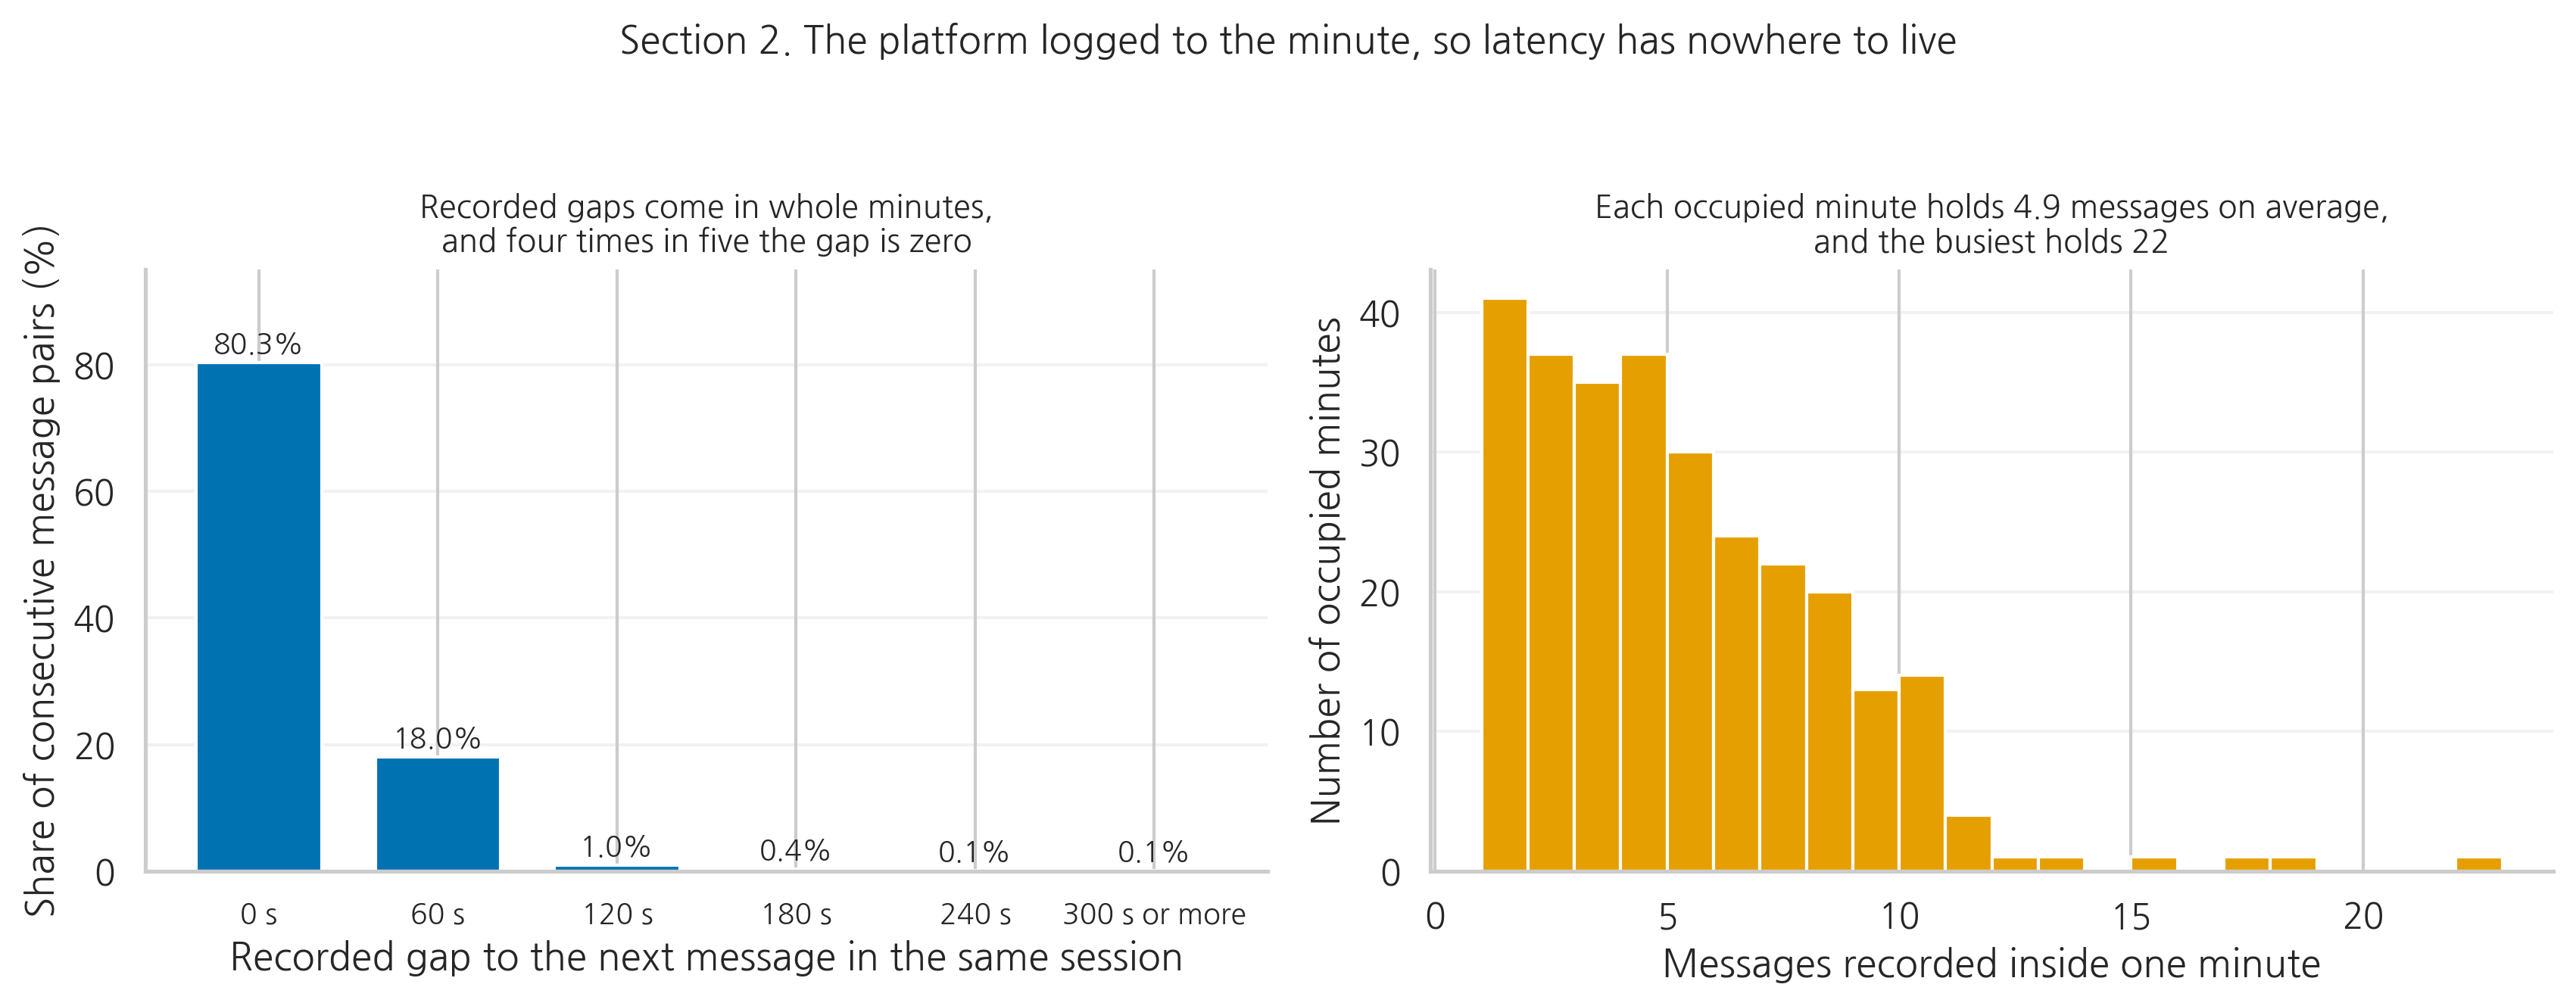

In [6]:
edges = [-30, 30, 90, 150, 210, 270, 1e9]
names = ["0 s", "60 s", "120 s", "180 s", "240 s", "300 s or more"]
shares = pd.cut(gaps, bins=edges, labels=names).value_counts(normalize=True).reindex(names)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

ax = axes[0]
ax.bar(range(len(names)), 100 * shares.values, color=OKABE["blue"], width=0.7)
for i, v in enumerate(100 * shares.values):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=9)
ax.set_xlabel("Recorded gap to the next message in the same session")
ax.set_ylabel("Share of consecutive message pairs (%)")
ax.set_title("Recorded gaps come in whole minutes,\nand four times in five the gap is zero", fontsize=10)
ax.set_ylim(0, 95)

ax = axes[1]
ax.hist(minute_bins.values, bins=range(1, int(minute_bins.max()) + 2),
        color=OKABE["orange"], edgecolor="white")
ax.set_xlabel("Messages recorded inside one minute")
ax.set_ylabel("Number of occupied minutes")
ax.set_title(f"Each occupied minute holds {len(chat) / len(minute_bins):.1f} messages on average,\n"
             f"and the busiest holds {minute_bins.max()}", fontsize=10)

for ax in axes:
    ax.grid(axis="y", alpha=0.25)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.suptitle("Section 2. The platform logged to the minute, so latency has nowhere to live", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

**Interpret this chart before you scroll.**

- The median latency is 0.0 seconds in every one of the sixteen sessions. That number reports the export
  format rather than how fast these groups answered each other.
- The mean of the same gaps is not zero, because the one pair in five that crosses a minute boundary drags
  it up. A dashboard reporting the mean would look like it was measuring something. What would it actually
  be counting?
- Suppose two groups genuinely differ: one answers in three seconds, the other in forty. What would this
  file show for each? Write the answer down. That answer is what resolution means.
- The general form of the question is the one to carry into your own project. Every log you will ever
  analyse was written by an engineer who was solving a different problem. Name one field in a dataset you
  care about whose precision you have not checked.

### The decision

**We retire the latency tile.** We do not report it with a caveat, and we do not substitute the mean. A
measure whose value is set by the logging format is a measure of the logging format, and putting a caveat
under it on a dashboard does not stop anyone reading the number.

What that costs us:

- No responsiveness measure, and no claim that a group answers each other quickly.
- No uptake speed, no measure of how long an idea sits before someone picks it up.
- No burst structure finer than a minute, so we cannot separate four people typing at once from four
  people typing in sequence within the same minute.

What survives the minute clock, because it never needed sub-minute resolution:

- **Who wrote how much**, which is Section 3, and which is exact.
- **Co-presence at minute grain**: whether two or more people wrote inside the same minute. That is a real
  interaction signal, and it is measured at the resolution the platform actually has.

The next cell computes the surviving measure. Notice that we are not salvaging the retired one. We are
asking a different, smaller question that the instrument can answer.

In [7]:
authors_per_minute = chat.groupby(["Group", "ts"])["authorid"].nunique()

print("WHAT A MINUTE CLOCK CAN STILL SUPPORT")
print("=" * 74)
print(f"  occupied minutes across all groups: {len(authors_per_minute)}")
print(f"  minutes containing messages from two or more people: "
      f"{int((authors_per_minute >= 2).sum())} = {100 * (authors_per_minute >= 2).mean():.1f}%")
print()
print("  share of a group's occupied minutes that hold two or more writers:")
for g, v in authors_per_minute.groupby(level=0).apply(lambda s: (s >= 2).mean()).items():
    bar = "#" * int(round(40 * v))
    print(f"    Group {g}  {100 * v:5.1f}%  {bar}")
print()
print("  Counts beside the rates, because a percentage of a small number is a small number:")
occ = authors_per_minute.groupby(level=0).size()
multi = authors_per_minute.groupby(level=0).apply(lambda s: int((s >= 2).sum()))
for g in occ.index:
    print(f"    Group {g}: {multi[g]} of {occ[g]} occupied minutes")

WHAT A MINUTE CLOCK CAN STILL SUPPORT
  occupied minutes across all groups: 283
  minutes containing messages from two or more people: 222 = 78.4%

  share of a group's occupied minutes that hold two or more writers:
    Group 1   62.9%  #########################
    Group 2   86.8%  ###################################
    Group 3   89.7%  ####################################
    Group 4   79.5%  ################################
    Group 5   81.4%  #################################
    Group 6   74.3%  ##############################
    Group 7   84.4%  ##################################
    Group 8   68.8%  ############################

  Counts beside the rates, because a percentage of a small number is a small number:
    Group 1: 22 of 35 occupied minutes
    Group 2: 33 of 38 occupied minutes
    Group 3: 26 of 29 occupied minutes
    Group 4: 31 of 39 occupied minutes
    Group 5: 35 of 43 occupied minutes
    Group 6: 26 of 35 occupied minutes
    Group 7: 27 of 32 occupied min

### Your turn 2: where does one stretch of talk end?

With latency retired, the natural temporal question becomes coarser: **how many separate stretches of
conversation did a session contain?** That needs a rule for how long a silence has to be before the
conversation has stopped rather than paused. There is no correct answer. Two minutes is a guess, and so
is any other number you pick.

Change `IDLE_MIN` and rerun. Try 1, then 5. Watch the count of stretches change and ask yourself which
version you would have reported if you had only run it once.

In [8]:
# TODO: try 1, then 5. The default of 2 already runs.
IDLE_MIN = 2

tmp = chat.copy()
tmp["new_stretch"] = tmp["gap_s"].isna() | (tmp["gap_s"] > IDLE_MIN * 60)
tmp["stretch_id"] = tmp.groupby("session")["new_stretch"].cumsum()
stretches = (tmp.groupby(["session", "stretch_id"])
                .agg(messages=("message", "size"), writers=("authorid", "nunique"),
                     minutes=("ts", lambda t: (t.max() - t.min()).total_seconds() / 60))
                .reset_index())

print(f"A stretch of talk ends after {IDLE_MIN} minute(s) with nothing recorded.")
print("=" * 74)
print(stretches.groupby("session")
               .agg(stretches=("messages", "size"), longest=("messages", "max"),
                    writers_in_longest=("writers", "max")).to_string())
print()
print(f"  total stretches across all 16 sessions: {len(stretches)}")
print(f"  stretches involving only one writer: {int((stretches.writers == 1).sum())} "
      f"of {len(stretches)} = {100 * (stretches.writers == 1).mean():.1f}%")
print(f"  median stretch: {stretches.messages.median():.0f} messages over "
      f"{stretches.minutes.median():.0f} minutes")

A stretch of talk ends after 2 minute(s) with nothing recorded.
                stretches  longest  writers_in_longest
session                                               
1 / 2021-02-15          1       71                   4
1 / 2021-02-17          4       33                   4
2 / 2021-02-15          1       80                   4
2 / 2021-02-17          1      103                   4
3 / 2021-02-16          1       82                   4
3 / 2021-02-18          2       56                   4
4 / 2021-02-16          1       74                   5
4 / 2021-02-18          4      100                   5
5 / 2021-02-16          1      148                   4
5 / 2021-02-18          1      112                   4
6 / 2021-02-16          1      104                   4
6 / 2021-02-18          1       70                   4
7 / 2021-02-16          1      102                   4
7 / 2021-02-18          2       64                   3
8 / 2021-02-16          1       53                   4
8

---

## Section 3. Who the log recorded, and how evenly

The **Gini coefficient** is a single number for how evenly a quantity is spread across the members of a
group, where 0 means every member is recorded identically. Week 6 did not use it, and the reason matters
here: every team in that corpus had exactly two children, and a Gini on two people adds nothing to what
the larger person's share already reports. Here the groups have four or five members, so the measure is
informative.

What matters most is the part dashboards get wrong. **The maximum is not 1.** For a group of *n* people
the ceiling is (n - 1) / n, reached only when one person does literally everything. Six of these groups
have four members, so their ceiling is **0.75**. Two have five, so theirs is **0.80**. Read every number
below against those, not against 1.0.

The warnings below are the reason this section is not simply Week 6 again.

**This measures the record, not the people.** A student who was reading carefully, talking on a parallel
voice call, or editing the shared document that this extract does not include, contributed nothing that
this file can see. The measure is *unevenness of recorded messages*, and that phrase is the only thing it
supports.

**Counts are lower bounds.** With no roster, anyone silent across all four days is absent from the
denominator, which pulls every Gini down. Three member-sessions do show somebody who typed on one day and
not the other, and those we fill in as zeros.

In [9]:
def gini(values):
    """Gini of non-negative contributions. 0 means every member recorded identically.
    Maximum is (n - 1) / n, not 1."""
    v = np.sort(np.asarray(values, dtype=float))
    n = v.size
    total = v.sum()
    if n == 0 or total <= 0:
        return 0.0
    index = np.arange(1, n + 1)
    return float((2.0 * np.sum(index * v)) / (n * total) - (n + 1.0) / n)


# The roster is whoever typed at least once across the four days, per group.
roster = {g: sorted(d["authorid"].unique()) for g, d in chat.groupby("Group")}

group_rows = []
for g, d in chat.groupby("Group"):
    counts = d["authorid"].value_counts().reindex(roster[g]).fillna(0)
    n = len(roster[g])
    group_rows.append(dict(group=g, members=n, messages=len(d), ceiling=(n - 1) / n,
                           gini=gini(counts.values),
                           top_share=counts.max() / len(d),
                           fewest_messages=int(counts.min())))
groups = pd.DataFrame(group_rows)
groups["top_share_x_even"] = groups["top_share"] * groups["members"]
groups["gini_vs_ceiling"] = groups["gini"] / groups["ceiling"]

sess_rows = []
for (g, d0), d in chat.groupby(["Group", "day"]):
    counts = d["authorid"].value_counts().reindex(roster[g]).fillna(0)
    sess_rows.append(dict(group=g, day=str(d0), messages=len(d), gini=gini(counts.values),
                          members_with_no_message=int((counts == 0).sum())))
sess = pd.DataFrame(sess_rows)

print("ONE ROW PER GROUP, BOTH DAYS POOLED")
print("top_share      = share held by the member with the most recorded messages")
print("top_share_x_even = that share as a multiple of an even split")
print("=" * 74)
print(groups.round(3).to_string(index=False))
print()
lo = groups.loc[groups.gini.idxmin()]
hi = groups.loc[groups.gini.idxmax()]
print(f"  Gini runs from {lo.gini:.3f} (Group {int(lo.group)}) to {hi.gini:.3f} "
      f"(Group {int(hi.group)}), a ratio of {hi.gini / lo.gini:.2f}")
print(f"  group sizes are {sorted(groups.members.unique())}, so this spread is not a size artifact")
print(f"  member-sessions where somebody who typed on one day typed nothing on the other: "
      f"{int(sess.members_with_no_message.sum())}")
print(sess[sess.members_with_no_message > 0].to_string(index=False))

ONE ROW PER GROUP, BOTH DAYS POOLED
top_share      = share held by the member with the most recorded messages
top_share_x_even = that share as a multiple of an even split
 group  members  messages  ceiling  gini  top_share  fewest_messages  top_share_x_even  gini_vs_ceiling
     1        4       129     0.75 0.099      0.295               21             1.178            0.132
     2        4       183     0.75 0.247      0.361                9             1.443            0.330
     3        4       152     0.75 0.188      0.414               26             1.658            0.250
     4        5       189     0.80 0.284      0.381               19             1.905            0.354
     5        4       260     0.75 0.304      0.473               24             1.892            0.405
     6        4       174     0.75 0.092      0.328               37             1.310            0.123
     7        4       181     0.75 0.231      0.376               20             1.503            0.3

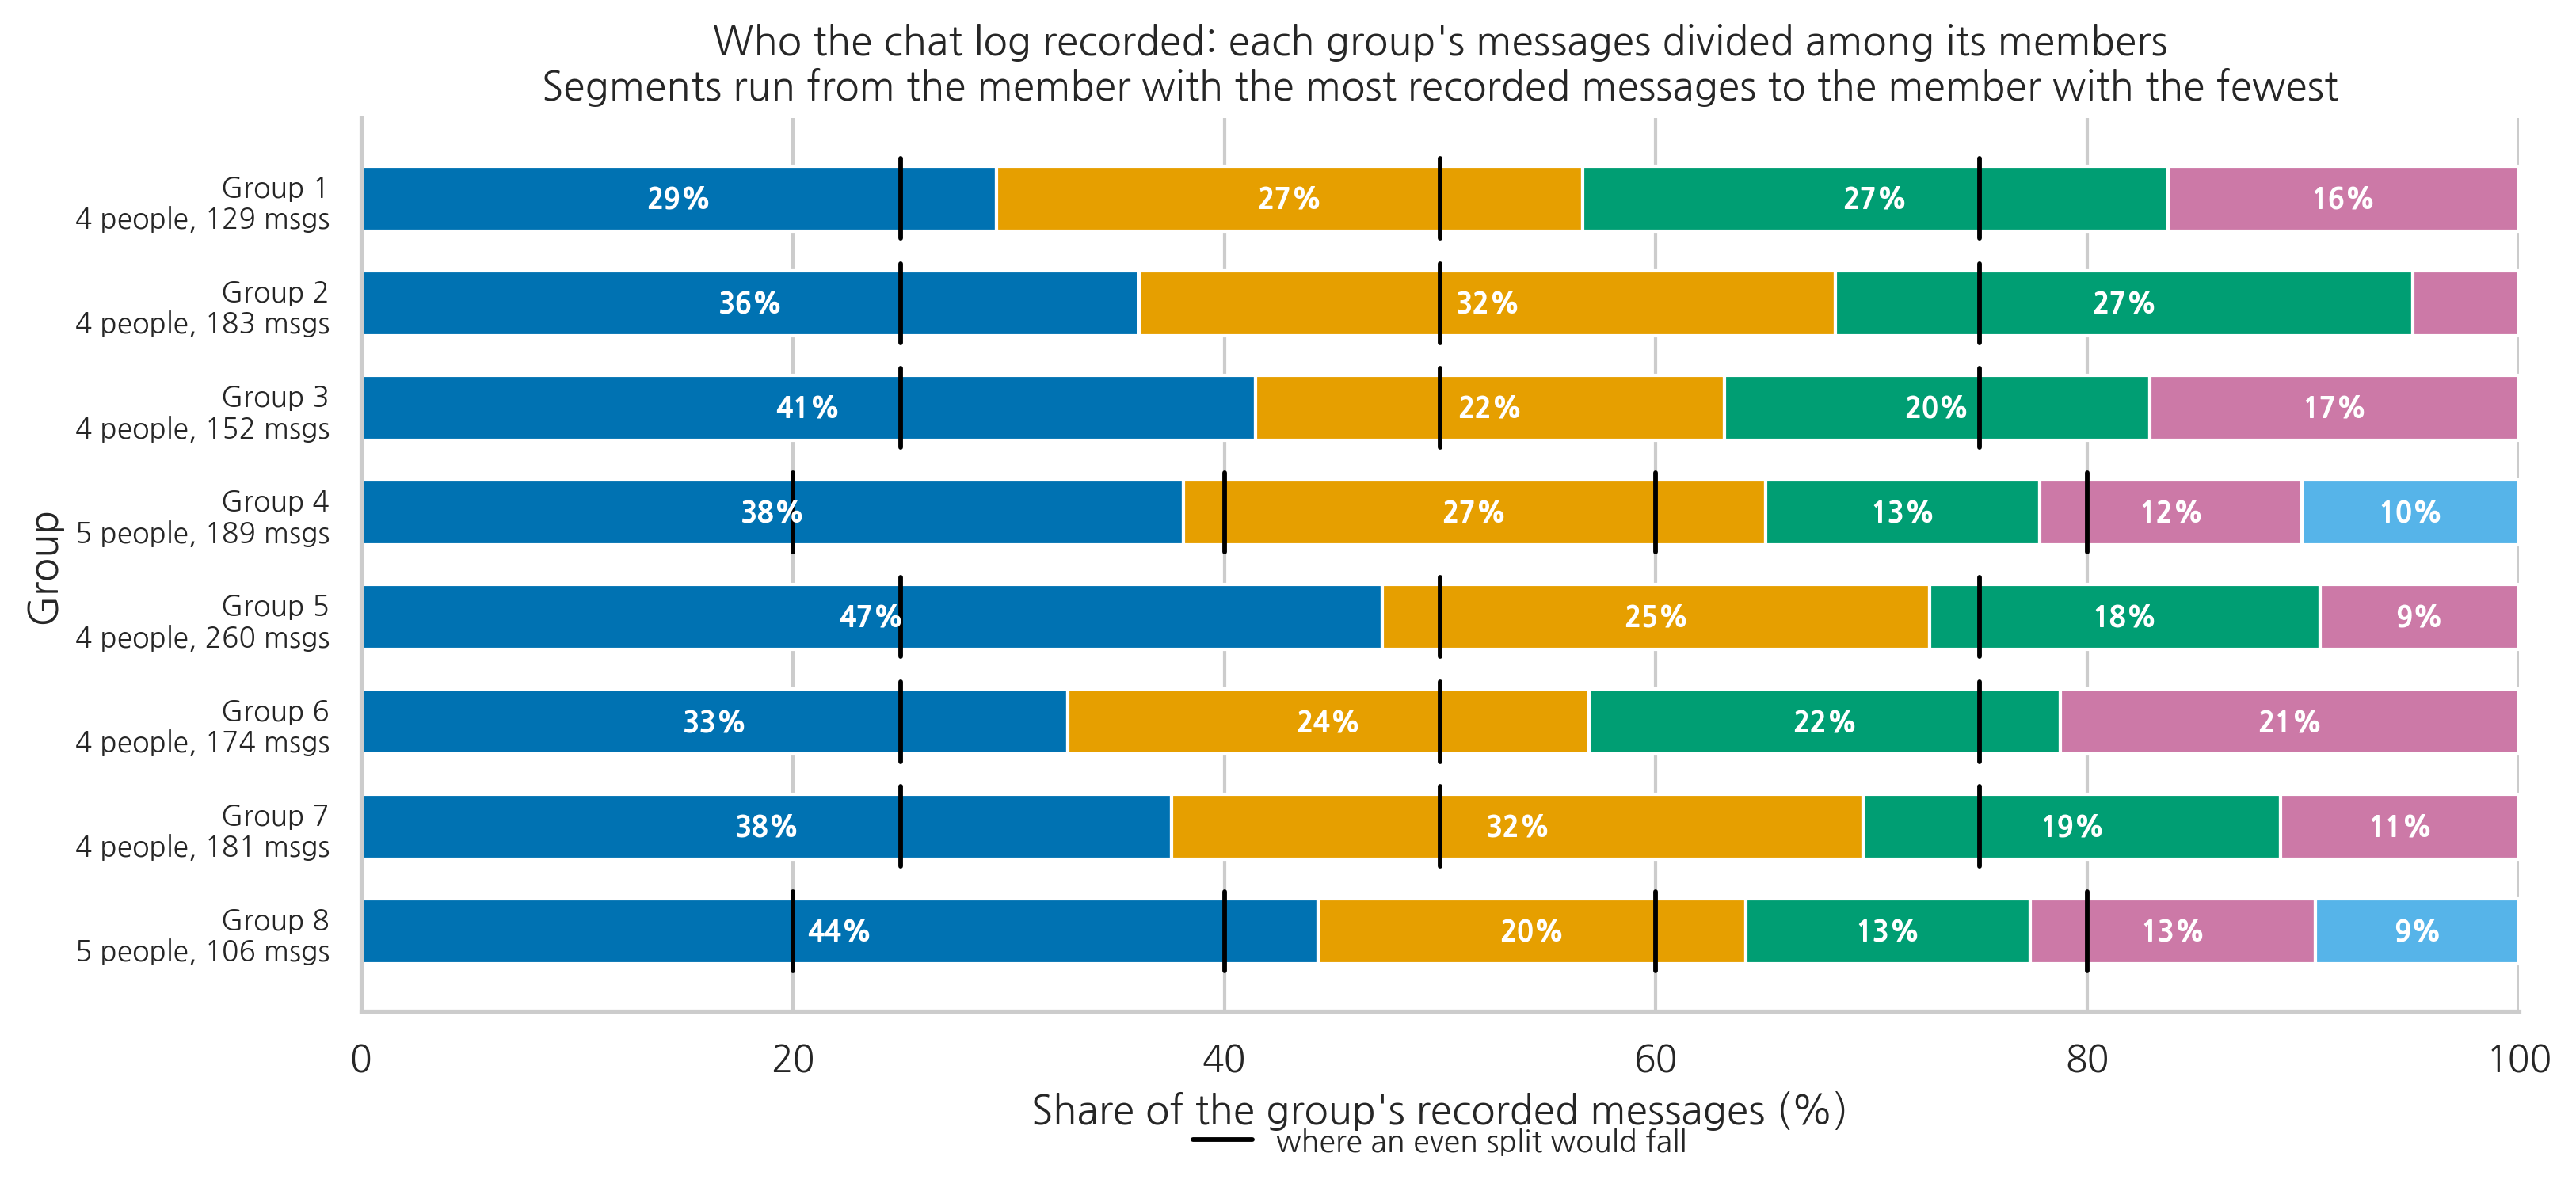

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.2))
ylabels = []
for i, g in enumerate(sorted(chat["Group"].unique())):
    counts = chat[chat["Group"] == g]["authorid"].value_counts().sort_values(ascending=False)
    total = counts.sum()
    left = 0.0
    for j, (_a, c) in enumerate(counts.items()):
        w = 100 * c / total
        ax.barh(i, w, left=left, color=MEMBER_COLORS[j], edgecolor="white", height=0.62)
        if w > 6:
            ax.text(left + w / 2, i, f"{w:.0f}%", ha="center", va="center",
                    fontsize=8.5, color="white", fontweight="bold")
        left += w
    n = len(counts)
    for k in range(1, n):
        ax.plot([100 * k / n] * 2, [i - 0.38, i + 0.38], color="black", linewidth=1.4)
    ylabels.append(f"Group {g}\n{n} people, {total} msgs")
ax.plot([], [], color="black", linewidth=1.4, label="where an even split would fall")
ax.set_yticks(range(len(ylabels)))
ax.set_yticklabels(ylabels, fontsize=8.5)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Share of the group's recorded messages (%)")
ax.set_ylabel("Group")
ax.set_title("Who the chat log recorded: each group's messages divided among its members\n"
             "Segments run from the member with the most recorded messages to the member with the fewest")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), frameon=False, fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Interpret this chart before you scroll.**

- Group 6's four segments are close to the black ticks. Group 8's are not: its most recorded member holds
  44 percent of 106 messages, which is 2.22 times an even share. Both pictures are of a real group that
  finished a real task, and this file records no outcome for either, so nothing here licenses a judgment
  about which group worked better.
- Before you explain any group's shape by the people in it, name three other explanations first. **The
  instrument:** this extract has the chat and not the shared document, so a member who wrote
  the document and typed little is recorded as a thin segment. **The setting:** a networks diagnosis task
  distributed across four or five people can be genuinely divisible, and a group that split it would look
  exactly like this. **The circumstances:** a session starting after ten at night on a Tuesday in February
  2021 is being fitted around the rest of somebody's life.
- The relabelling in Your turn 1 ordered members by message count. Look at what that ordering does to this
  chart: every group's segments descend, so every group looks like it has a leading contributor, including
  the ones that do not. Which visual features here are properties of the group and which are properties of
  the sort order?

---

## Section 4. How much of that spread is chance, how much is the group, and how much is the day

A threefold spread in Gini across eight groups looks like a finding. The questions below have to be
answered before it is one, and they separate a doctoral reading from a dashboard.

**1. What would this look like if nobody differed at all?** Even if every member of a group were exactly
as likely as every other to take the next turn, the counts would still come out uneven, because random
allocation is lumpy. So there is a floor, and the floor is not zero. It depends on three things: the group
size, the number of messages, and **how bursty the talk is**. That third one is the one people forget.
Messages in a chat are not independent events, because people send two or three in a row, and a null that
pretends otherwise puts the floor too low and makes every group look further above chance than it is. The
next cell simulates both nulls, 20,000 draws per group, so you can see how much that mistake is worth.

**2. Is unevenness a property of the group or of the day?** Each group here was recorded twice. If the
measure is a stable property of a group, its two days should agree. If they do not, then a dashboard
reading one session is labelling a Tuesday, not a team.

**3. How many independent things are we actually looking at?** Not 1,374. Messages sit inside people,
people sit inside groups, and the two sessions of a group are the same five people twice. **Eight groups
is the number that constrains every group-level claim in this notebook**, and eight is very small.

In [11]:
def gini_rows(matrix):
    """Gini of every row of a matrix at once."""
    m = np.sort(matrix, axis=1)
    n = m.shape[1]
    totals = m.sum(axis=1)
    idx = np.arange(1, n + 1)
    return (2.0 * (m * idx).sum(axis=1)) / (n * totals) - (n + 1.0) / n


def chance_gini_naive(n_members, n_messages, draws=20000, seed=8100):
    """Gini if every member were equally likely to send each message, one at a time.

    This is the null almost everybody reaches for, and it is the wrong one for a
    chat log, for the reason the next function fixes. It stays here so you can see
    the size of the mistake rather than take our word for it.
    """
    rng = np.random.default_rng(seed)
    sim = rng.multinomial(int(n_messages), np.repeat(1.0 / n_members, n_members), size=draws)
    return gini_rows(sim)


def run_lengths(frame, group_col="session"):
    """Lengths of the runs of consecutive messages by the same person."""
    out = []
    for _, d in frame.groupby(group_col):
        a = d.sort_values("ts")["authorid"].to_numpy()
        n = 1
        for i in range(1, len(a)):
            if a[i] == a[i - 1]:
                n += 1
            else:
                out.append(n)
                n = 1
        out.append(n)
    return np.array(out)


def chance_gini_bursty(n_members, runs, n_turns=None, draws=20000, seed=8100):
    """The same null, but keeping the fact that people send messages in runs.

    The naive version treats 1,374 messages as 1,374 independent events. They are
    not. People type two or three lines in a row, and in this file a run averages
    about 1.4 messages and reaches 7. Independent draws are smoother than bursty
    ones, so the naive floor sits TOO LOW, and a floor that sits too low makes
    every group look further above chance than it is. That is exactly the
    non-independence the nesting box below is about, arriving inside the null
    model rather than inside a test, which is where it is hardest to notice.

    So here each TURN is handed to a member at random, and each turn carries a run
    length resampled from that group's own runs. Members stay exchangeable, which
    is what "nobody differed" has to mean; only the lumpiness is preserved.
    """
    rng = np.random.default_rng(seed)
    runs = np.asarray(runs)
    if n_turns is None:
        n_turns = len(runs)
    who = rng.integers(0, n_members, size=(draws, n_turns))
    lens = rng.choice(runs, size=(draws, n_turns), replace=True)
    sim = np.empty((draws, n_members), dtype=float)
    for m in range(n_members):
        sim[:, m] = np.where(who == m, lens, 0).sum(axis=1)
    keep = sim.sum(axis=1) > 0
    return gini_rows(sim[keep])


ALL_RUNS = run_lengths(chat)
print("HOW BURSTY IS THIS CHAT, AND WHY THE NULL HAS TO KNOW")
print("=" * 74)
print(f"  {len(chat)} messages arrive in {len(ALL_RUNS)} runs by a single person, so a run")
print(f"  averages {ALL_RUNS.mean():.2f} messages and reaches {ALL_RUNS.max()}. Messages are not")
print("  independent events, so we simulate turns, not messages.")
print()

rows = []
for _, r in groups.iterrows():
    rl = run_lengths(chat[chat["Group"] == r.group])
    naive = chance_gini_naive(int(r.members), int(r.messages))
    bursty = chance_gini_bursty(int(r.members), rl)
    rows.append(dict(group=int(r.group),
                     naive_floor=naive.mean(),
                     chance_mean=bursty.mean(),
                     chance_p95=np.percentile(bursty, 95),
                     share_of_chance_runs_at_least_this_uneven=float((bursty >= r.gini).mean()),
                     p_naive=float((naive >= r.gini).mean())))
groups = groups.merge(pd.DataFrame(rows), on="group")
groups["above_chance"] = groups["gini"] - groups["chance_mean"]

print("HOW UNEVEN WOULD THESE GROUPS LOOK IF NOBODY DIFFERED AT ALL?")
print("chance_mean and chance_p95 keep the burst structure. naive_floor does not.")
print("=" * 74)
print(groups[["group", "members", "messages", "gini", "naive_floor", "chance_mean",
              "chance_p95", "share_of_chance_runs_at_least_this_uneven", "above_chance"]]
      .round(4).to_string(index=False))
print()
print("  The honest floor sits above the naive one in every group, by "
      f"{100 * (groups.chance_mean / groups.naive_floor - 1).mean():.0f}% on average.")
print("  Had we drawn the naive one, every group would have looked further above chance")
print("  than it is, and the two flattest groups would have looked further above zero.")
print()
print(f"  groups more uneven than 95% of equal-propensity simulations: "
      f"{int((groups.share_of_chance_runs_at_least_this_uneven < 0.05).sum())} of {len(groups)}")
print("  groups this file cannot separate from chance:",
      groups.loc[groups.share_of_chance_runs_at_least_this_uneven >= 0.05, "group"].tolist())
print("  and under the naive floor the same verdict:",
      groups.loc[groups.p_naive >= 0.05, "group"].tolist())
print("  The verdict happens to survive the correction here. The floors do not, and if you")
print("  ever report a distance from a floor rather than a verdict, the floor is the number.")
print()
print(f"  the floor itself moves: {groups.chance_mean.min():.3f} for Group "
      f"{int(groups.loc[groups.chance_mean.idxmin(), 'group'])} (most messages) up to "
      f"{groups.chance_mean.max():.3f} for Group "
      f"{int(groups.loc[groups.chance_mean.idxmax(), 'group'])} (fewest messages, five members)")
print(f"  most uneven by raw Gini      : Group {int(groups.loc[groups.gini.idxmax(), 'group'])}")
print(f"  most uneven above its own floor: Group {int(groups.loc[groups.above_chance.idxmax(), 'group'])}")
print("  the two rankings disagree at the top, and only one of them adjusts for message volume.")
print()
print("  One more thing to say out loud: that is eight groups each compared with its own")
print("  floor, which is eight chances to find something. We describe where each group sits")
print("  relative to its own null. We do not test eight hypotheses and report the winners.")


HOW BURSTY IS THIS CHAT, AND WHY THE NULL HAS TO KNOW
  1374 messages arrive in 982 runs by a single person, so a run
  averages 1.40 messages and reaches 7. Messages are not
  independent events, so we simulate turns, not messages.



HOW UNEVEN WOULD THESE GROUPS LOOK IF NOBODY DIFFERED AT ALL?
chance_mean and chance_p95 keep the burst structure. naive_floor does not.
 group  members  messages   gini  naive_floor  chance_mean  chance_p95  share_of_chance_runs_at_least_this_uneven  above_chance
     1        4       129 0.0988       0.0745       0.0920      0.1591                                     0.4024        0.0068
     2        4       183 0.2473       0.0627       0.0773      0.1357                                     0.0000        0.1700
     3        4       152 0.1875       0.0688       0.0857      0.1494                                     0.0066        0.1018
     4        5       189 0.2836       0.0732       0.1036      0.1696                                     0.0000        0.1800
     5        4       260 0.3038       0.0526       0.0769      0.1345                                     0.0000        0.2270
     6        4       174 0.0920       0.0642       0.0910      0.1586                         

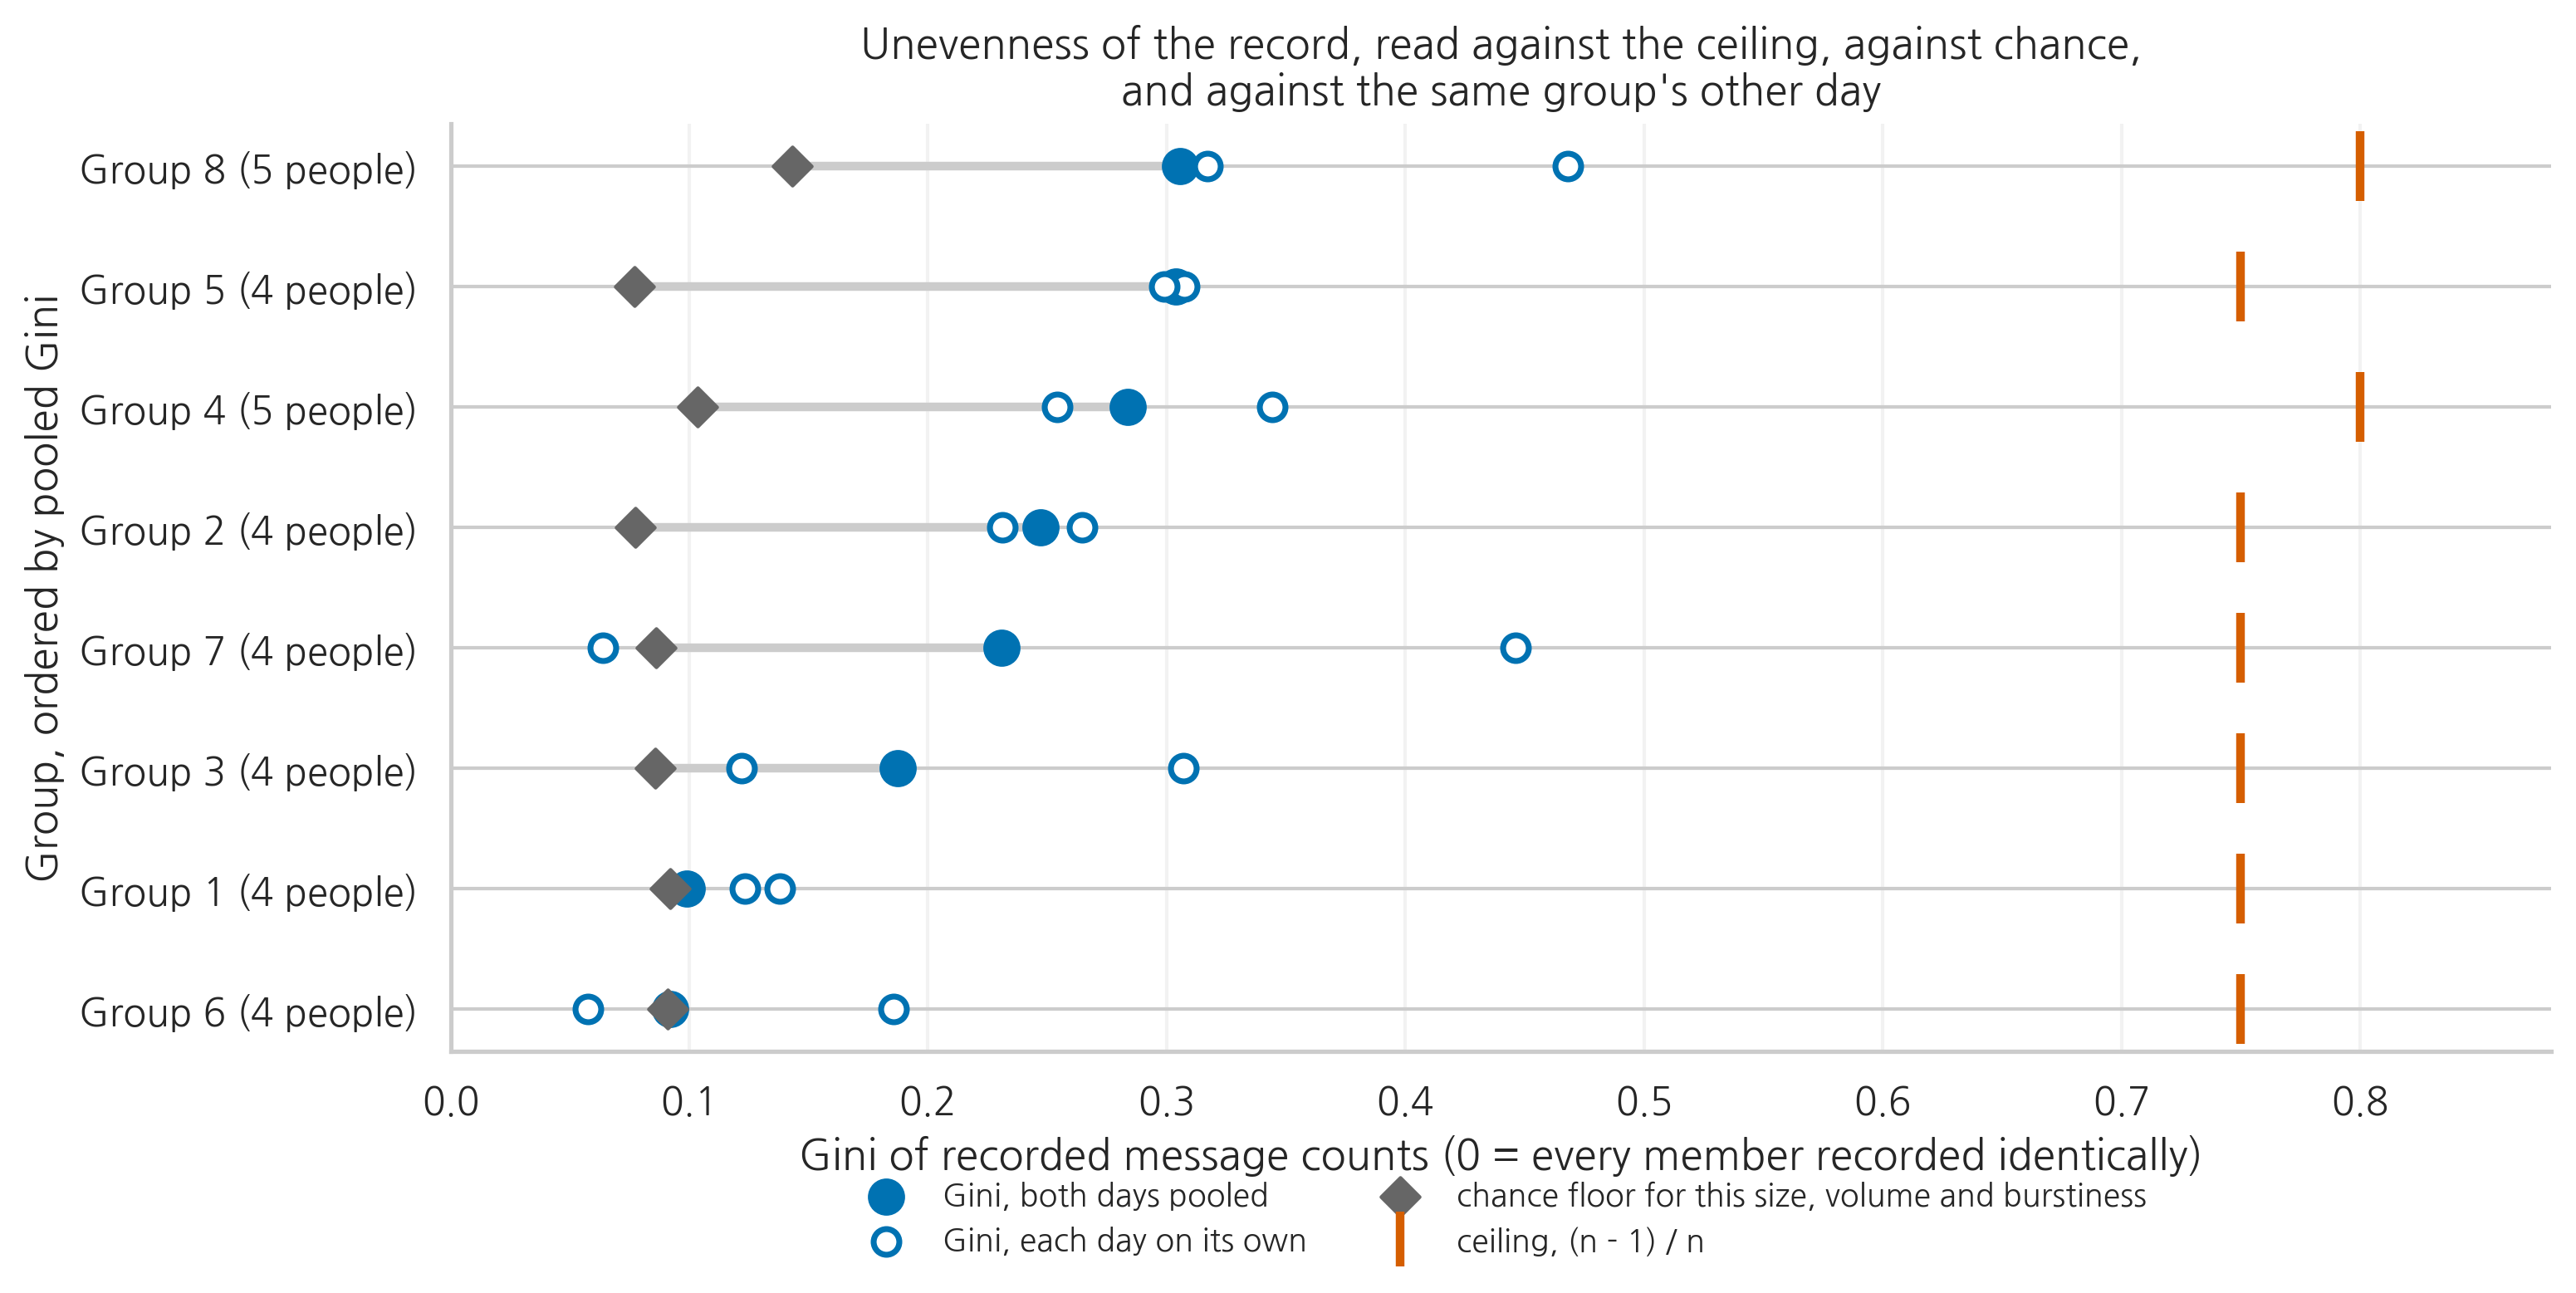

THE SAME GROUP, MEASURED ON ITS TWO DAYS
         min    max  swing
group                     
1      0.123  0.138  0.015
2      0.231  0.265  0.033
3      0.122  0.307  0.185
4      0.254  0.344  0.090
5      0.299  0.307  0.008
6      0.058  0.186  0.128
7      0.064  0.446  0.382
8      0.317  0.468  0.151

  widest day-to-day swing inside a single group: 0.382 (Group 7, 0.064 then 0.446)
  full spread across all eight groups, both days pooled: 0.214
  groups whose own two days differ by more than that whole spread: 1


In [12]:
fig, ax = plt.subplots(figsize=(10.5, 5.4))
gs = groups.sort_values("gini").reset_index(drop=True)
for i, r in gs.iterrows():
    ax.plot([r.chance_mean, r.gini], [i, i], color="#cccccc", linewidth=2.5, zorder=1)
    days = sess[sess.group == r.group]
    ax.scatter(days.gini, [i] * len(days), s=55, facecolors="white",
               edgecolors=OKABE["blue"], linewidths=1.7, zorder=5)
    ax.scatter([r.gini], [i], s=95, color=OKABE["blue"], zorder=4)
    ax.scatter([r.chance_mean], [i], s=62, marker="D", color=OKABE["grey"], zorder=4)
    ax.plot([r.ceiling], [i], marker="|", markersize=20, markeredgewidth=2.5,
            color=OKABE["red"], zorder=4)
ax.scatter([], [], s=95, color=OKABE["blue"], label="Gini, both days pooled")
ax.scatter([], [], s=55, facecolors="white", edgecolors=OKABE["blue"], linewidths=1.7,
           label="Gini, each day on its own")
ax.scatter([], [], s=62, marker="D", color=OKABE["grey"],
           label="chance floor for this size, volume and burstiness")
ax.plot([], [], marker="|", linestyle="none", markersize=16, markeredgewidth=2.5,
        color=OKABE["red"], label="ceiling, (n - 1) / n")
ax.set_yticks(range(len(gs)))
ax.set_yticklabels([f"Group {int(r.group)} ({int(r.members)} people)" for _, r in gs.iterrows()])
ax.set_xlim(0, 0.88)
ax.set_xlabel("Gini of recorded message counts (0 = every member recorded identically)")
ax.set_ylabel("Group, ordered by pooled Gini")
ax.set_title("Unevenness of the record, read against the ceiling, against chance,\n"
             "and against the same group's other day")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.11), ncol=2, frameon=False, fontsize=9)
ax.grid(axis="x", alpha=0.25)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

swing = sess.groupby("group").gini.agg(["min", "max"])
swing["swing"] = swing["max"] - swing["min"]
between = groups.gini.max() - groups.gini.min()
print("THE SAME GROUP, MEASURED ON ITS TWO DAYS")
print("=" * 74)
print(swing.round(3).to_string())
print()
print(f"  widest day-to-day swing inside a single group: {swing.swing.max():.3f} "
      f"(Group {swing.swing.idxmax()}, {swing.loc[swing.swing.idxmax(), 'min']:.3f} then "
      f"{swing.loc[swing.swing.idxmax(), 'max']:.3f})")
print(f"  full spread across all eight groups, both days pooled: {between:.3f}")
print(f"  groups whose own two days differ by more than that whole spread: "
      f"{int((swing.swing > between).sum())}")

**Interpret this chart before you scroll.**

- Every filled dot sits well left of its red ceiling tick. None of these groups is anywhere near one
  person holding everything. If a dashboard scaled this measure to a 0 to 1 bar, every group would look
  more uneven than it is.
- Groups 1 and 6 sit close to their grey diamonds. Their message counts are no more uneven than equal
  turn-taking propensities would produce on their own, so "these two groups shared the chat evenly" is a
  claim this file cannot distinguish from "these two groups were four people taking turns at random". Six
  of the eight do clear their own floor.
- Note where the diamonds are. They are the burst-preserving floors, which sit about a third higher than
  the naive ones printed beside them, and Group 8's is nearly half again as high. The verdict, six of
  eight, happens to be the same under either null. The **distances** are not, and a distance from a floor
  is the number people actually quote.
- Now the open circles. Group 7's two days are 0.064 and 0.446. That single group's swing, 0.382, is
  **larger than the entire spread across all eight groups**, which is 0.214. Say out loud what that does
  to any dashboard that reports this measure after one session.
- You should be able to argue both readings of that swing. (a) The measure is noisy at this
  sample size, and one 79 message session cannot pin it down. (b) The measure is fine and groups genuinely
  reorganise between sittings, which is what a group of people doing a two-part task would do. What
  evidence in this notebook helps you choose, and what evidence would you need that is not here?

### What is nested inside what

Please write the structure down, because it is the same structure in almost every collaboration dataset you will
ever meet:

```
1,374 messages
   nested inside 34 people
      nested inside 8 groups
         each observed on 2 days
```

A test that treats the 1,374 messages as independent observations is claiming 1,374 independent chances to
be wrong, when the real number is closer to 8. That is not a small correction. It turns an interval you
could publish into a number that only looks precise.

Concretely, for anything in this section:

- **Person-level claims** have at most 34 units, and the 34 are not independent either, because four or
  five of them shared a conversation.
- **Group-level claims have 8 units.** With eight points, a rank correlation has to be enormous
  before it means anything, and the interval around it will run most of the way from -1 to +1.
- **Session-level claims have 16 units**, but the sixteen are eight groups measured twice, so they are
  worth somewhere between 8 and 16 depending on how much of the variation sits between groups. The two-day
  swings above say: not much of it does.

So the next cell asks a question this file genuinely cannot settle, and reports the uncertainty rather
than the point estimate. **The right output of a question this file cannot answer is a wide interval.**

DOES A GROUP THAT SENDS MORE MESSAGES SPREAD THEM MORE EVENLY?
  Spearman across 8 groups: +0.26
  95% bootstrap interval  : [-0.59, +1.00]   (4000 usable resamples of 8 groups)

  That interval covers almost the whole range a correlation can take. The honest sentence is
  'this file cannot tell', and it is a complete answer.

  What we can say without a test: the group with the most messages is Group 5 (260 messages),
  and its Gini of 0.304 ranks 2 of 8 for unevenness. Whatever else is true,
  'the more a group talks, the more evenly it shares the floor' is not visible here.


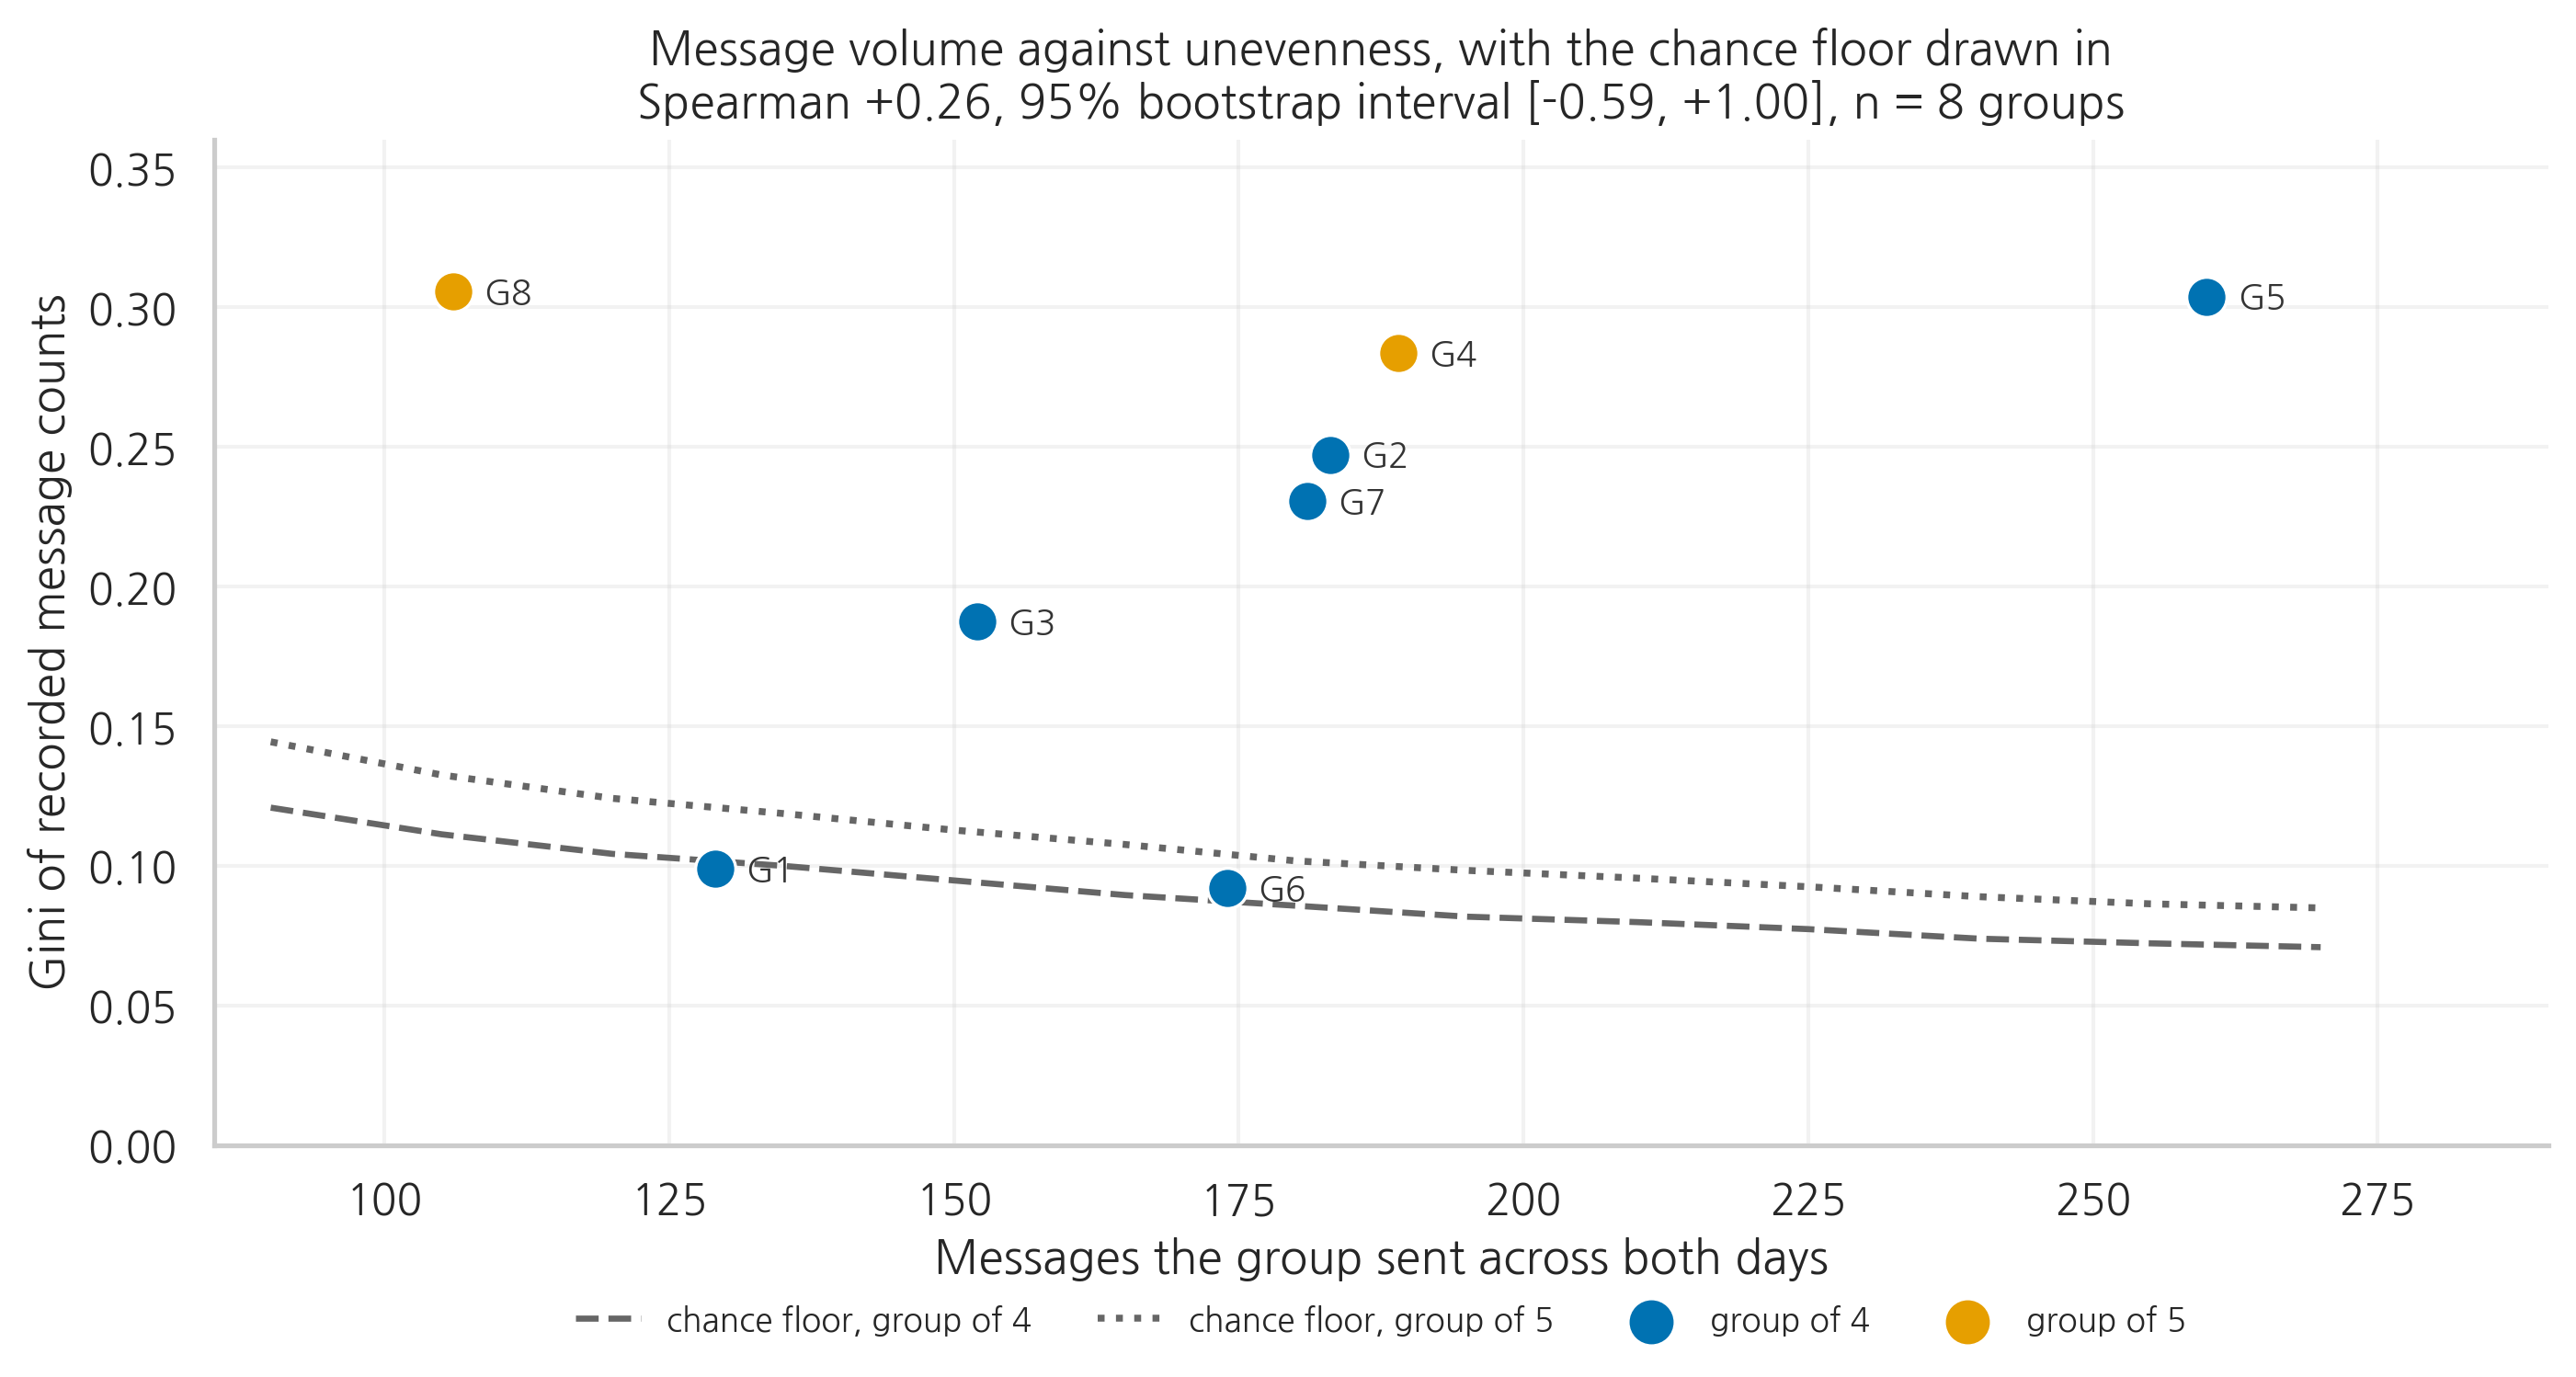

In [13]:
def spearman_with_ci(x, y, draws=4000, seed=8100):
    """Spearman correlation with a bootstrap interval, resampling whole units."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    rng = np.random.default_rng(seed)
    obs = stats.spearmanr(x, y).statistic
    keep = []
    for _ in range(draws):
        i = rng.integers(0, len(x), len(x))
        if len(np.unique(x[i])) < 3 or len(np.unique(y[i])) < 3:
            continue
        keep.append(stats.spearmanr(x[i], y[i]).statistic)
    lo, hi = np.nanpercentile(keep, [2.5, 97.5])
    return obs, lo, hi, len(keep)


r_vol = spearman_with_ci(groups.messages, groups.gini)

print("DOES A GROUP THAT SENDS MORE MESSAGES SPREAD THEM MORE EVENLY?")
print("=" * 74)
print(f"  Spearman across 8 groups: {r_vol[0]:+.2f}")
print(f"  95% bootstrap interval  : [{r_vol[1]:+.2f}, {r_vol[2]:+.2f}]   "
      f"({r_vol[3]} usable resamples of 8 groups)")
print()
print("  That interval covers almost the whole range a correlation can take. The honest sentence is")
print("  'this file cannot tell', and it is a complete answer.")
print()
busiest = groups.loc[groups.messages.idxmax()]
rank = int(groups.gini.rank(ascending=False)[groups.messages.idxmax()])
print(f"  What we can say without a test: the group with the most messages is Group "
      f"{int(busiest.group)} ({int(busiest.messages)} messages),")
print(f"  and its Gini of {busiest.gini:.3f} ranks {rank} of 8 for unevenness. Whatever else is true,")
print("  'the more a group talks, the more evenly it shares the floor' is not visible here.")

# The chance floor falls as volume rises, so draw it rather than subtracting it.
# Same null as the diamonds above: turns, not messages. A group with m messages
# has roughly m / (mean run length) turns, and the runs are resampled from the
# whole file because a hypothetical group has no runs of its own.
grid = np.arange(90, 285, 15)
MEAN_RUN = ALL_RUNS.mean()


def floor_curve(n_members, m):
    turns = max(1, int(round(m / MEAN_RUN)))
    return chance_gini_bursty(n_members, ALL_RUNS, n_turns=turns, draws=4000).mean()


floor4 = [floor_curve(4, m) for m in grid]
floor5 = [floor_curve(5, m) for m in grid]

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(grid, floor4, linestyle="--", color=OKABE["grey"], linewidth=1.6,
        label="chance floor, group of 4")
ax.plot(grid, floor5, linestyle=":", color=OKABE["grey"], linewidth=1.8,
        label="chance floor, group of 5")
for _, r in groups.iterrows():
    colour = OKABE["blue"] if r.members == 4 else OKABE["orange"]
    ax.scatter(r.messages, r.gini, s=110, color=colour, zorder=3, edgecolors="white", linewidths=0.8)
    ax.annotate(f"G{int(r.group)}", (r.messages, r.gini), textcoords="offset points",
                xytext=(8, -3), fontsize=9, color="#333333")
ax.scatter([], [], s=110, color=OKABE["blue"], label="group of 4")
ax.scatter([], [], s=110, color=OKABE["orange"], label="group of 5")
ax.set_xlim(85, 290)
ax.set_ylim(0, 0.36)
ax.set_xlabel("Messages the group sent across both days")
ax.set_ylabel("Gini of recorded message counts")
ax.set_title("Message volume against unevenness, with the chance floor drawn in\n"
             f"Spearman {r_vol[0]:+.2f}, 95% bootstrap interval "
             f"[{r_vol[1]:+.2f}, {r_vol[2]:+.2f}], n = 8 groups")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=4, frameon=False, fontsize=8.5)
ax.grid(alpha=0.25)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Interpret this chart before you scroll.**

- The two grey lines are the reason we drew the floor instead of subtracting it. The floor falls as volume
  rises, so a measure like "Gini minus chance" is correlated with volume **by construction**, and a
  correlation you built into a statistic is not evidence. Drawing the floor makes visible the same
  adjustment without hiding it inside a number.
- Please read the vertical distance from each point to its own dashed line. Group 5 sits furthest above its
  floor even though Group 8 has the higher raw Gini, because Group 8 sent 106 messages and Group 5 sent
  260. Which of those two groups would you call the more uneven, and what does your answer commit you to?
- Eight points. Cover any one of them with your thumb and ask whether the shape you were about to describe
  is still there. Do it for Group 8, then for Group 5. The bootstrap interval removes points the same way,
  4,000 times.

### Your turn 3: change what counts as a contribution

Counting messages treats `si` and a two-line diagnosis of a switch as the same contribution. Nearly three
in ten of the messages in this file are two words or fewer. Real text gives you an alternative a message count cannot
reach: count **characters** or **words** actually typed.

The default below is `"characters"`, and it already runs. Try `"words"`, and try `"messages"` to see the
comparison collapse into a straight line. Then answer the question underneath: when a measure barely
changes the ranking, is that reassuring, or does it mean neither measure is seeing the thing you care
about?

In [14]:
# TODO: try "words", then "messages". Options: "messages", "characters", "words".
MEASURE = "characters"

chat["chars"] = chat["message"].astype(str).str.len()
chat["words"] = chat["message"].astype(str).str.split().str.len()

if MEASURE == "messages":
    contrib = chat.groupby(["Group", "authorid"]).size()
elif MEASURE == "characters":
    contrib = chat.groupby(["Group", "authorid"])["chars"].sum()
elif MEASURE == "words":
    contrib = chat.groupby(["Group", "authorid"])["words"].sum()
else:
    raise ValueError("MEASURE must be 'messages', 'characters' or 'words'")

alt = contrib.groupby(level=0).apply(lambda s: gini(s.values))
compare = pd.DataFrame({"gini_messages": groups.set_index("group").gini,
                        f"gini_{MEASURE}": alt})
compare["rank_messages"] = compare["gini_messages"].rank()
compare[f"rank_{MEASURE}"] = compare[f"gini_{MEASURE}"].rank()
rho = stats.spearmanr(compare["gini_messages"], compare[f"gini_{MEASURE}"]).statistic

print(f"Unevenness in {MEASURE}, next to unevenness in messages")
print("=" * 74)
print(compare.round(3).to_string())
print()
print(f"  Spearman between the two rankings: {rho:+.3f}")
print(f"  messages that are two words or fewer: {100 * (chat.words <= 2).mean():.1f}%")
print(f"  median message length: {chat.chars.median():.0f} characters, "
      f"longest {chat.chars.max()}")
print(f"  total across the file: {int(chat.chars.sum())} characters, {int(chat.words.sum())} words")

Unevenness in characters, next to unevenness in messages
   gini_messages  gini_characters  rank_messages  rank_characters
1          0.099            0.079            2.0              1.0
2          0.247            0.261            5.0              6.0
3          0.188            0.177            3.0              3.0
4          0.284            0.236            6.0              5.0
5          0.304            0.301            7.0              8.0
6          0.092            0.132            1.0              2.0
7          0.231            0.218            4.0              4.0
8          0.306            0.273            8.0              7.0

  Spearman between the two rankings: +0.929
  messages that are two words or fewer: 28.5%
  median message length: 23 characters, longest 224
  total across the file: 40413 characters, 7943 words


---

## Section 5. Does any of this travel?

Everything above describes eight groups of undergraduates typing Spanish at each other in February 2021.
Nothing above tells you whether it describes collaboration.

So we change almost everything at once and look again. Week 6's dataset: 78 children aged 9 to 12, in 39
teams of **two**, in a room with a robot, building a minimum spanning tree together, in a different
country, a different language, a different medium, and a different decade of schooling. Two channels are
recorded per child, **interface actions** for everyone and **speech** for a subset, and a team level
**learning outcome** exists, which the chat data does not have at all.

That last point is why the second setting is here. In the chat data we could describe unevenness and
nothing else, because the file records no outcome. Here we can finally ask the question the whole field
wants answered: **does a more evenly shared record go with a better result?**

Note the ceiling and the sample sizes before the numbers.

**The ceiling changes.** For a team of two, (n - 1) / n = **0.5**. A Gini of 0.25 in a dyad is half the
maximum possible; the same 0.25 in a group of four is a third of the maximum. Comparing raw Ginis across
group sizes is a mistake, so below we compare the **share held by the member with the most recorded
activity, expressed as a multiple of an even split**, which is defined the same way at any group size, and
we draw the chance floor for each setting beside it. For the speech channel the floor is computed on
**speaking turns** rather than seconds, because a floor needs countable events and a second is not one.
Say what that substitution costs: seconds arrive in turn-sized lumps of very different length, so the real
floor for a share of seconds is higher than the floor for a share of turns. The green floor below is
therefore a lower bound, and the gap you see above it is an upper bound on the real one.

**The numbers are small.** There are 39 teams, of which 34 have an outcome row and 10 have speech, and
nine have both. Every interval below is built on those counts and none of them is large.

In [15]:
pair = children.pivot(index="team_no", columns="who")


def dyad_gini(a, b):
    """Gini for a team of two. Equals |a - b| / (2 (a + b)); its ceiling is 0.5."""
    if pd.isna(a) or pd.isna(b) or (a + b) <= 0:
        return np.nan
    return abs(a - b) / (2.0 * (a + b))


just = pd.DataFrame({
    "team": pair.index,
    "actions_total": pair[("actions", "A")] + pair[("actions", "B")],
    "turns_total": pair[("turns", "A")] + pair[("turns", "B")],
    "gini_actions": [dyad_gini(a, b) for a, b in zip(pair[("actions", "A")], pair[("actions", "B")])],
    "gini_speech": [dyad_gini(a, b) for a, b in zip(pair[("speech_secs", "A")], pair[("speech_secs", "B")])],
    "mean_gain": (pair[("gain", "A")] + pair[("gain", "B")]) / 2.0,
}).reset_index(drop=True)
# For a dyad, the busiest share as a multiple of an even split is exactly 1 + 2 * Gini.
just["top_x_even_actions"] = 1 + 2 * just["gini_actions"]
just["top_x_even_speech"] = 1 + 2 * just["gini_speech"]

merged = just.merge(teams_out[["team", "last_error", "T_LG_absolute"]], on="team", how="left")

print("THE SECOND SETTING: JUSThink, the children from Week 6")
print("=" * 74)
print(f"  children                          : {len(children)}")
print(f"  teams                             : {children.team_no.nunique()}, "
      f"every one of them exactly {children.groupby('team_no').size().unique()[0]} children")
print(f"  children with speech transcribed  : {int(children.speech_secs.notna().sum())} "
      f"({int(merged.gini_speech.notna().sum())} teams)")
print(f"  teams with a learning outcome row : {int(merged.T_LG_absolute.notna().sum())}")
print(f"  teams with speech AND an outcome  : "
      f"{int(merged.dropna(subset=['gini_speech', 'T_LG_absolute']).shape[0])}")
missing_teams = sorted(set(children.team_no) - set(teams_out.team.astype(int)))
print(f"  teams with no outcome row         : {missing_teams}")
print("  We do not know why those five are missing, so we report the drop rather than hiding it.")
print()
print("A CHECK WE CAN RUN BECAUSE TWO FILES DESCRIBE THE SAME CHILDREN")
print("=" * 74)
chk = merged.dropna(subset=["T_LG_absolute"])
print("  T_LG_absolute should equal the pair's mean test change divided by 10.")
print(f"  largest disagreement across {len(chk)} teams: "
      f"{(chk.mean_gain / 10 - chk.T_LG_absolute).abs().max():.6f}")
print("  It matches exactly, which tells us the derived column means what we think it means.")
print()
print("BASE RATES, BEFORE ANY COMPARISON")
print("=" * 74)
print(f"  pre-test mean {children.score_pre.mean():.2f} of 10, "
      f"post-test mean {children.score_post.mean():.2f}")
print(f"  teams whose pair average rose: {int((merged.mean_gain > 0).sum())}, "
      f"unchanged: {int((merged.mean_gain == 0).sum())}, "
      f"fell: {int((merged.mean_gain < 0).sum())}, out of {len(merged)}")
print("  Most teams barely moved. Any correlate of 'learning gain' here is a correlate of a small,")
print("  coarse, ten-point difference, and that limits what it can support before we compute anything.")
print()
print(f"  ceiling on the Gini for a team of two: {(2 - 1) / 2:.2f}")
print(f"  interface actions, {int(just.gini_actions.notna().sum())} teams: Gini "
      f"{just.gini_actions.min():.3f} to {just.gini_actions.max():.3f}, "
      f"mean {just.gini_actions.mean():.3f}")
sp = just.dropna(subset=["gini_speech"])
print(f"  speech seconds,    {len(sp)} teams: Gini "
      f"{sp.gini_speech.min():.3f} to {sp.gini_speech.max():.3f}, mean {sp.gini_speech.mean():.3f}")

THE SECOND SETTING: JUSThink, the children from Week 6
  children                          : 78
  teams                             : 39, every one of them exactly 2 children
  children with speech transcribed  : 20 (10 teams)
  teams with a learning outcome row : 34
  teams with speech AND an outcome  : 9
  teams with no outcome row         : [11, 33, 34, 35, 36]
  We do not know why those five are missing, so we report the drop rather than hiding it.

A CHECK WE CAN RUN BECAUSE TWO FILES DESCRIBE THE SAME CHILDREN
  T_LG_absolute should equal the pair's mean test change divided by 10.
  largest disagreement across 34 teams: 0.000000
  It matches exactly, which tells us the derived column means what we think it means.

BASE RATES, BEFORE ANY COMPARISON
  pre-test mean 5.85 of 10, post-test mean 5.95
  teams whose pair average rose: 17, unchanged: 8, fell: 14, out of 39
  Most teams barely moved. Any correlate of 'learning gain' here is a correlate of a small,
  coarse, ten-point diffe

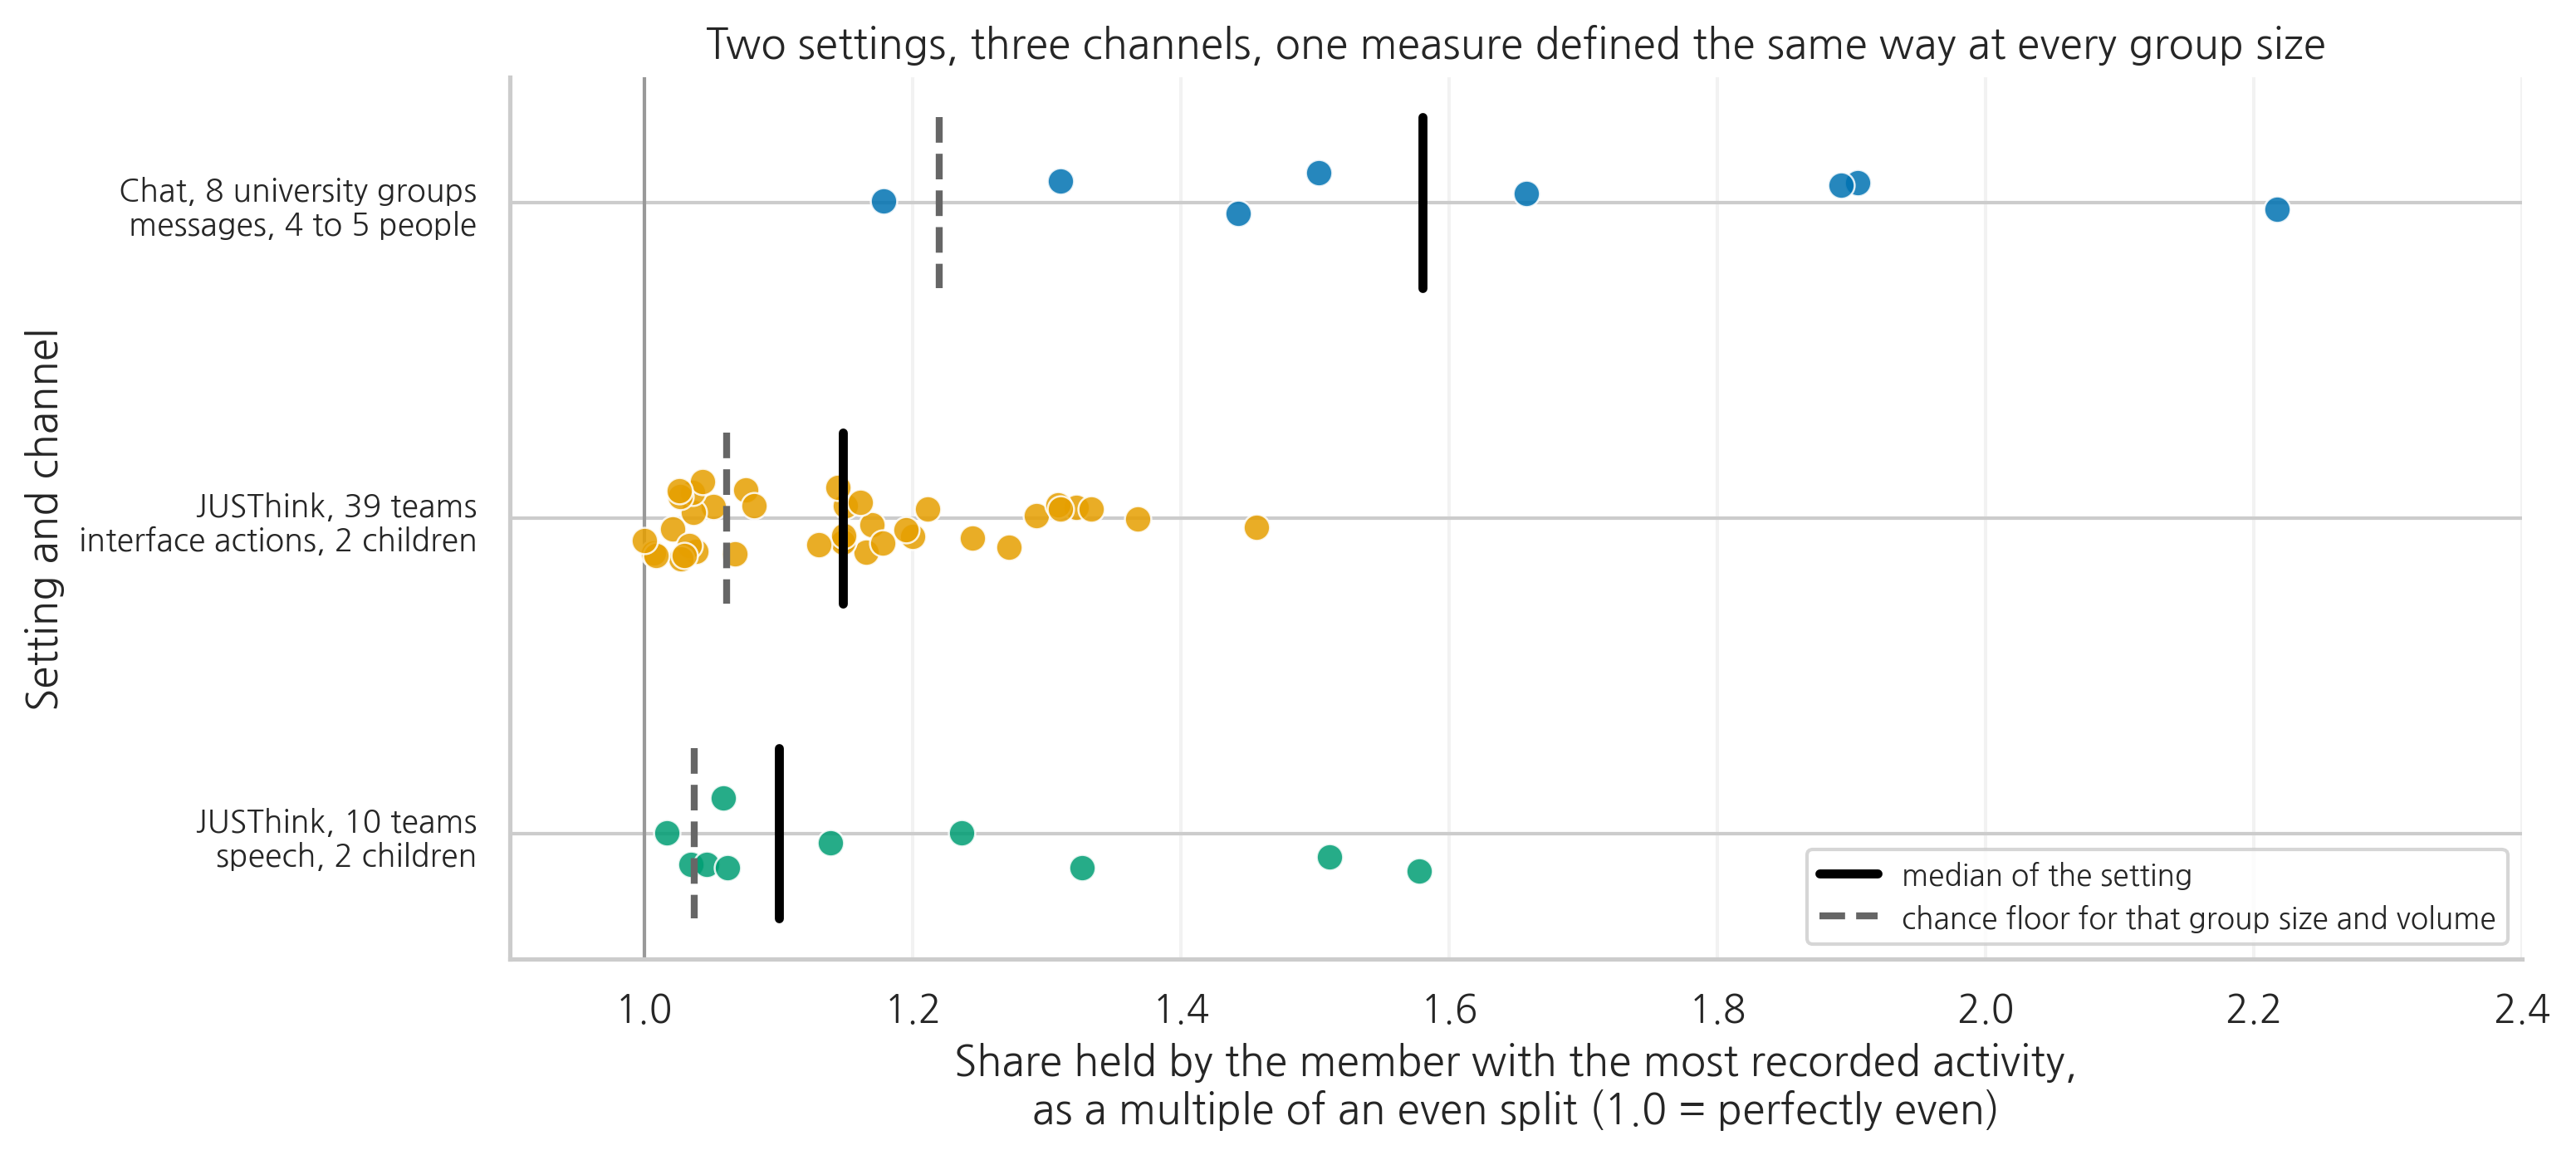

  Chat, 8 university groups    n=  8   range 1.18 to 2.22   median 1.58   chance floor 1.22
  JUSThink, 39 teams           n= 39   range 1.00 to 1.46   median 1.15   chance floor 1.06
  JUSThink, 10 teams           n= 10   range 1.02 to 1.58   median 1.10   chance floor 1.04


In [16]:
def chance_top_x_even(n_members, n_units, draws=4000, seed=8100):
    """Chance level for 'busiest share as a multiple of an even split'.

    Independent events. Correct for the two JUSThink channels only in the weak
    sense that we have no sequence for them and so cannot do better: an interface
    click and a speaking turn are certainly bursty too, so these two floors are
    LOWER BOUNDS on the real ones, and the strip below says so.
    """
    rng = np.random.default_rng(seed)
    sim = rng.multinomial(int(n_units), np.repeat(1.0 / n_members, n_members), size=draws)
    return float((sim.max(axis=1) / n_units * n_members).mean())


def chance_top_x_even_bursty(n_members, runs, draws=4000, seed=8100):
    """The chat version, keeping the runs, exactly as in Section 4."""
    rng = np.random.default_rng(seed)
    runs = np.asarray(runs)
    n_turns = len(runs)
    who = rng.integers(0, n_members, size=(draws, n_turns))
    lens = rng.choice(runs, size=(draws, n_turns), replace=True)
    sim = np.empty((draws, n_members), dtype=float)
    for m in range(n_members):
        sim[:, m] = np.where(who == m, lens, 0).sum(axis=1)
    tot = sim.sum(axis=1)
    return float((sim.max(axis=1) / tot * n_members).mean())


chat_chance = np.median([chance_top_x_even_bursty(
    int(r.members), run_lengths(chat[chat["Group"] == r.group]))
    for _, r in groups.iterrows()])
act_chance = np.median([chance_top_x_even(2, t) for t in just.actions_total])
sp_chance = np.median([chance_top_x_even(2, t) for t in just.turns_total.dropna()])

strips = [
    ("Chat, 8 university groups\nmessages, 4 to 5 people",
     groups.top_share_x_even.values, chat_chance, OKABE["blue"]),
    ("JUSThink, 39 teams\ninterface actions, 2 children",
     just.top_x_even_actions.dropna().values, act_chance, OKABE["orange"]),
    ("JUSThink, 10 teams\nspeech, 2 children",
     just.top_x_even_speech.dropna().values, sp_chance, OKABE["green"]),
]

fig, ax = plt.subplots(figsize=(10.5, 4.8))
jit = np.random.default_rng(8100)
for i, (name, vals, ch, colour) in enumerate(strips):
    ax.scatter(vals, i + jit.uniform(-0.13, 0.13, len(vals)), s=58, color=colour,
               alpha=0.85, edgecolors="white", linewidths=0.6, zorder=3)
    ax.plot([np.median(vals)] * 2, [i - 0.27, i + 0.27], color="black", linewidth=2.6, zorder=4)
    ax.plot([ch] * 2, [i - 0.27, i + 0.27], color=OKABE["grey"], linewidth=2.0,
            linestyle="--", zorder=4)
ax.plot([], [], color="black", linewidth=2.6, label="median of the setting")
ax.plot([], [], color=OKABE["grey"], linewidth=2.0, linestyle="--",
        label="chance floor for that group size and volume")
ax.axvline(1.0, color="#999999", linewidth=1.0)
ax.set_yticks(range(len(strips)))
ax.set_yticklabels([s[0] for s in strips], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0.9, 2.4)
ax.set_xlabel("Share held by the member with the most recorded activity,\n"
              "as a multiple of an even split (1.0 = perfectly even)")
ax.set_ylabel("Setting and channel")
ax.set_title("Two settings, three channels, one measure defined the same way at every group size")
ax.legend(loc="lower right", frameon=True, fontsize=8.5)
ax.grid(axis="x", alpha=0.25)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

for name, vals, ch, _ in strips:
    print(f"  {name.splitlines()[0]:<28} n={len(vals):>3}   "
          f"range {vals.min():.2f} to {vals.max():.2f}   median {np.median(vals):.2f}   "
          f"chance floor {ch:.2f}")

**Interpret this chart before you scroll.**

- The chat groups sit further above their floor than either JUSThink channel does. That is the honest
  statement, and it comes with a caveat that runs against it: the chat floor keeps the burst structure of
  real typing, and the two JUSThink floors cannot, because those files record totals and not sequences.
  Clicks and speaking turns are bursty too, so the orange and green floors are lower bounds and the gap
  above them is an upper bound. The comparison survives, and it is smaller than it looks.
  It is also **not** "university students collaborate less evenly than children", and the reasons
  are worth listing before anyone says it out loud: a two person team has only one way to be uneven, the
  JUSThink pairs sat side by side with a robot prompting them, the chat sessions were online and
  seventeen minutes long, and the two records count entirely different things.
- Look at the dashed floors. They are not in the same place, and they move for a purely arithmetic reason:
  a two way split of two hundred actions is a smoother draw than a four way split of a hundred messages.
  A dashboard comparing groups of different sizes with a single threshold is comparing them against
  different implicit nulls without knowing it.
- One team in the JUSThink action panel sits at exactly 1.00, a perfect even split. With 110 actions, how
  surprised should you be? Answer with the floor rather than with intuition.

DOES A MORE EVENLY SHARED RECORD GO WITH A BETTER RESULT?
  action Gini vs absolute learning gain, 34 teams: Spearman -0.008   95% interval [-0.37, +0.36]
  action Gini vs final task error,       34 teams: Spearman -0.183   95% interval [-0.50, +0.18]
  action Gini vs speech Gini,            10 teams: Spearman -0.200   95% interval [-0.80, +0.63]

  Three intervals, all wide, one of them enormous. Note what the first one rules OUT:
  with 34 teams the interval excludes anything past about |0.4|, so a strong relationship
  between action unevenness and learning gain is not hiding here. A weak one might be.

  Note also that three comparisons is already three chances to find something. We report all
  three rather than the best one, and we describe the intervals rather than testing each cell.


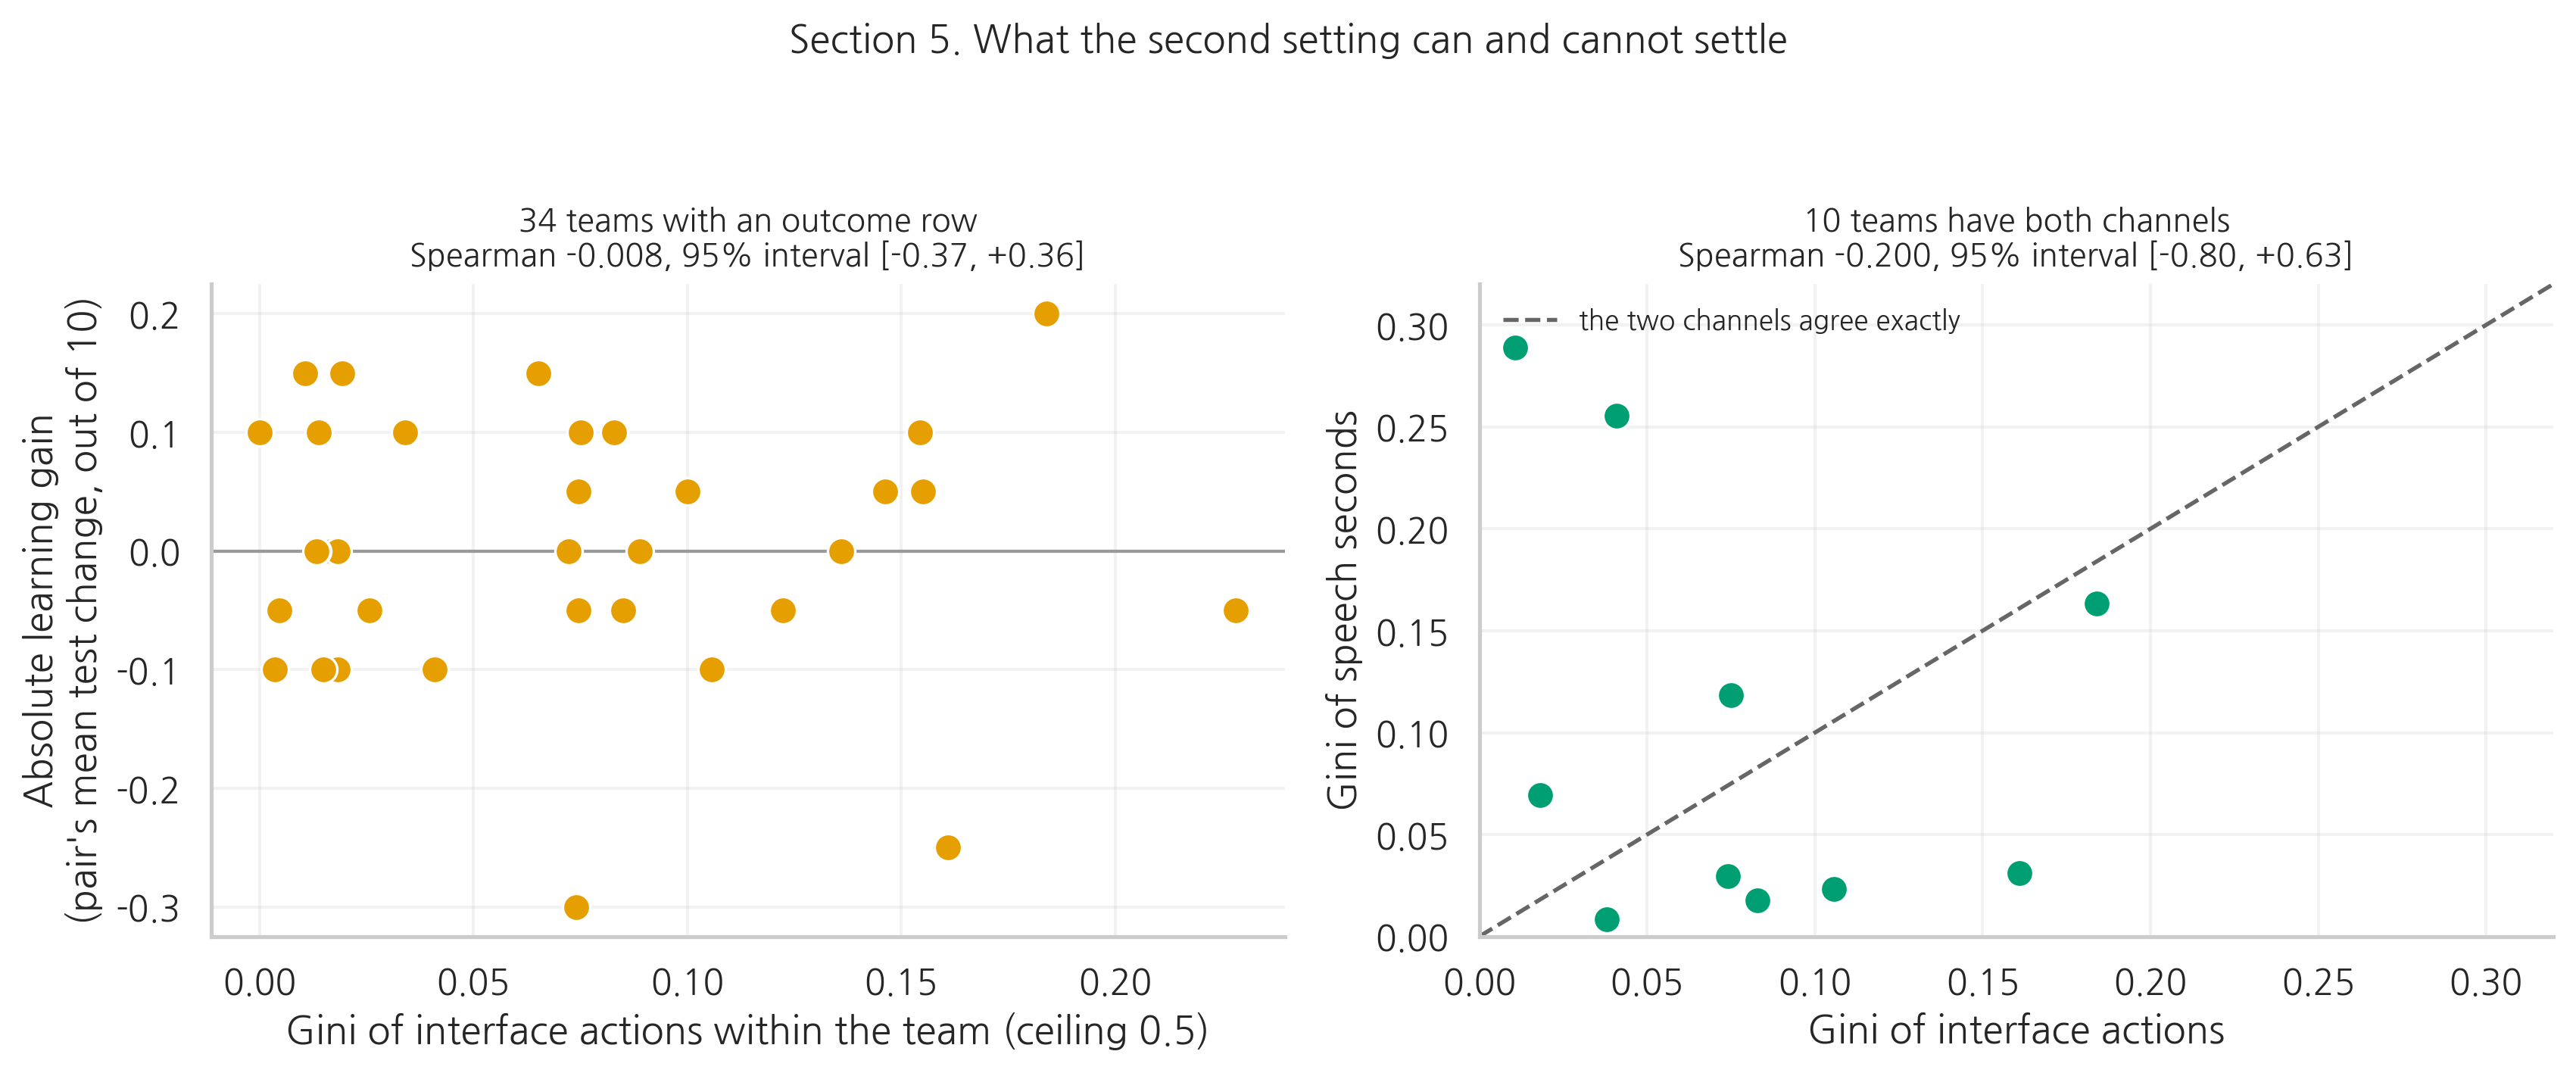

In [17]:
have = merged.dropna(subset=["T_LG_absolute"])
r_gain = spearman_with_ci(have.gini_actions, have.T_LG_absolute)
r_err = spearman_with_ci(have.gini_actions, have.last_error)
both = merged.dropna(subset=["gini_speech", "gini_actions"])
r_chan = spearman_with_ci(both.gini_actions, both.gini_speech)

print("DOES A MORE EVENLY SHARED RECORD GO WITH A BETTER RESULT?")
print("=" * 74)
print(f"  action Gini vs absolute learning gain, {len(have):>2} teams: "
      f"Spearman {r_gain[0]:+.3f}   95% interval [{r_gain[1]:+.2f}, {r_gain[2]:+.2f}]")
print(f"  action Gini vs final task error,       {len(have):>2} teams: "
      f"Spearman {r_err[0]:+.3f}   95% interval [{r_err[1]:+.2f}, {r_err[2]:+.2f}]")
print(f"  action Gini vs speech Gini,            {len(both):>2} teams: "
      f"Spearman {r_chan[0]:+.3f}   95% interval [{r_chan[1]:+.2f}, {r_chan[2]:+.2f}]")
print()
print("  Three intervals, all wide, one of them enormous. Note what the first one rules OUT:")
print("  with 34 teams the interval excludes anything past about |0.4|, so a strong relationship")
print("  between action unevenness and learning gain is not hiding here. A weak one might be.")
print()
print("  Note also that three comparisons is already three chances to find something. We report all")
print("  three rather than the best one, and we describe the intervals rather than testing each cell.")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

ax = axes[0]
ax.scatter(have.gini_actions, have.T_LG_absolute, s=75, color=OKABE["orange"],
           edgecolors="white", linewidths=0.8, zorder=3)
ax.axhline(0, color="#999999", linewidth=1.0)
ax.set_xlabel("Gini of interface actions within the team (ceiling 0.5)")
ax.set_ylabel("Absolute learning gain\n(pair's mean test change, out of 10)")
ax.set_title(f"{len(have)} teams with an outcome row\n"
             f"Spearman {r_gain[0]:+.3f}, 95% interval [{r_gain[1]:+.2f}, {r_gain[2]:+.2f}]",
             fontsize=10)

ax = axes[1]
ax.scatter(both.gini_actions, both.gini_speech, s=75, color=OKABE["green"],
           edgecolors="white", linewidths=0.8, zorder=3)
lim = 0.32
ax.plot([0, lim], [0, lim], linestyle="--", color=OKABE["grey"], linewidth=1.3,
        label="the two channels agree exactly")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Gini of interface actions")
ax.set_ylabel("Gini of speech seconds")
ax.set_title(f"{len(both)} teams have both channels\n"
             f"Spearman {r_chan[0]:+.3f}, 95% interval [{r_chan[1]:+.2f}, {r_chan[2]:+.2f}]",
             fontsize=10)
ax.legend(loc="upper left", frameon=False, fontsize=8.5)

for ax in axes:
    ax.grid(alpha=0.25)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.suptitle("Section 5. What the second setting can and cannot settle", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

**Interpret these charts before you scroll.**

- Left panel. The correlation between how unevenly a pair used the interface and how much the pair's test
  score moved is essentially zero, with an interval running from about -0.37 to +0.36. Write the sentence
  you would say to a colleague who claimed "we know balanced participation drives learning". Then write
  the sentence you would say to a colleague who claimed "we have shown it does not."
- The outcome itself is coarse. A pair's mean gain moves in steps of half a point on a ten point test, and
  most pairs did not move at all. Before blaming the collaboration measure, ask how much room the outcome
  measure left it.
- Right panel. Ten teams have both channels, and the two channels do not line up. That is exactly the
  Week 6 lesson, arriving again in a different dataset: **which sensor you own decides which teams look
  uneven.** But the interval here runs from -0.80 to +0.63, so the correct reading is not "the channels
  disagree", it is "ten teams cannot tell us whether they agree." Notice how different those two
  sentences are, and how easily the first gets written.
- You now have evidence for a design question. If you had to pick one channel to build a dashboard on,
  the interface log is cheap, complete for all 39 teams, and unrelated to the outcome here. The speech
  transcript is expensive, exists for 10 teams, and cannot be evaluated at that size. What do you do,
  and what do you tell the school you did?

---

## Section 6. The design question

The discussion block opens on this section.

You have now built, and in one case retired, a set of candidate tiles.

### Your turn 4: assign every tile an audience

Below is a draft specification for a collaboration dashboard for a course like the one in the chat data.
For each tile you decide the audience:

- `"teacher"`: only the instructor sees it
- `"group"`: displayed to the whole group during or after the session
- `"student"`: each student sees only their own value
- `"nobody"`: the tile is not built, or is built and never displayed

The cell checks your specification against a list of hazards **drawn only from what this notebook actually
found**, and prints a review. The defaults already produce a coherent and arguable specification, so the
cell runs untouched. Change at least three, and be ready to explain the changes.

One principle to examine: a measure may be shown to an audience only if that audience can act on it in
a way that helps, and only if being wrong about a person costs less than staying silent.

In [18]:
# TODO: edit the audience for each tile. Options: "teacher", "group", "student", "nobody".
dashboard_spec = {
    "group_message_volume":        "group",
    "median_response_latency":     "teacher",
    "message_count_gini":          "teacher",
    "gini_against_chance_floor":   "teacher",
    "per_member_message_count":    "student",
    "per_member_share_vs_even":    "group",
    "co_presence_minutes":         "group",
    "single_session_snapshot":     "teacher",
    "name_attached_to_author_id":  "nobody",
    "predicted_group_outcome":     "nobody",
}

HAZARDS = {
    "median_response_latency": (
        "Section 2: this platform logs to the minute, so the median is 0.0 s in 16 of 16 sessions. "
        "The tile reports the export format, not the group.",
        {"teacher", "group", "student"}),
    "message_count_gini": (
        "Section 4: two of the eight groups sit inside their own chance floor, and one group's two "
        "days differ by more than the whole spread across groups. Shown as a group property it is "
        "not one.",
        {"group", "student"}),
    "per_member_message_count": (
        "Section 3 and Your turn 3: 28.5% of messages are two words or fewer, so the count equates "
        "'si' with a diagnosis. Shown to peers it turns a proxy into a target.",
        {"group"}),
    "per_member_share_vs_even": (
        "Section 3: this file has no roster, so a member who never typed is missing from the "
        "denominator, and the extract holds the chat without the shared document. The share is a "
        "lower bound on one channel, displayed as if it were participation.",
        {"group", "student"}),
    "single_session_snapshot": (
        "Section 4: Group 7 reads 0.064 on one day and 0.446 on the other. A one session label is a "
        "label about a day that will follow people for a term.",
        {"group", "student"}),
    "name_attached_to_author_id": (
        "The published data are pseudonymous; a course platform is not. Re-attaching names converts "
        "every tile above into a record about a named person.",
        {"teacher", "group", "student"}),
    "predicted_group_outcome": (
        "Section 5: across 34 teams the interval on unevenness against learning gain runs about "
        "-0.37 to +0.36. There is nothing here to predict from, and a prediction shown before the "
        "work is finished can become the reason it comes true.",
        {"teacher", "group", "student"}),
}

print("COLLABORATION DASHBOARD SPECIFICATION")
print("=" * 74)
for tile, audience in dashboard_spec.items():
    mark = "  " if audience == "nobody" else "> "
    print(f"{mark}{tile:30s} -> {audience}")

print()
print("DESIGN REVIEW")
print("=" * 74)
flags = 0
for tile, audience in dashboard_spec.items():
    note, risky = HAZARDS.get(tile, (None, set()))
    if note and audience in risky:
        flags += 1
        print(f"\n[!] {tile} -> {audience}")
        for line in note.split(". "):
            if line.strip():
                print(f"    {line.strip().rstrip('.')}.")
if flags == 0:
    print("\nNo hazard on the list was triggered. That is not the same as a safe dashboard:")
    print("the list holds only the hazards this notebook happened to surface, and this notebook")
    print("looked at eight groups for four days.")
else:
    print(f"\n{flags} tile(s) flagged. A flag is not a verdict. It is the start of the argument you")
    print("have to make, in writing, to the people whose collaboration is on the screen.")

shown = sum(1 for a in dashboard_spec.values() if a != "nobody")
print(f"\nYou chose to display {shown} of {len(dashboard_spec)} tiles.")
print("Every tile you kept is a claim you are willing to defend to a student who disagrees with it.")

COLLABORATION DASHBOARD SPECIFICATION
> group_message_volume           -> group
> median_response_latency        -> teacher
> message_count_gini             -> teacher
> gini_against_chance_floor      -> teacher
> per_member_message_count       -> student
> per_member_share_vs_even       -> group
> co_presence_minutes            -> group
> single_session_snapshot        -> teacher
  name_attached_to_author_id     -> nobody
  predicted_group_outcome        -> nobody

DESIGN REVIEW

[!] median_response_latency -> teacher
    Section 2: this platform logs to the minute, so the median is 0.0 s in 16 of 16 sessions.
    The tile reports the export format, not the group.

[!] per_member_share_vs_even -> group
    Section 3: this file has no roster, so a member who never typed is missing from the denominator, and the extract holds the chat without the shared document.
    The share is a lower bound on one channel, displayed as if it were participation.

2 tile(s) flagged. A flag is not a verd

### Your turn 5: write the refusal

One question is harder than any individual slot. Finish this sentence in the cell below, with something
you would actually say in a faculty meeting:

> A collaboration dashboard for this course should not show ______ to ______, because ______.

Then answer the follow up that always comes next and that this notebook cannot answer for you: **who gets
to make that decision, and were the students in the room when it was made?**

In [19]:
# TODO: replace the text between the quotes. Nothing depends on what you write here.
my_refusal = ("A collaboration dashboard for this course should not show ... to ... "
              "because ...")
who_decides = "..."

print("MY REFUSAL")
print("=" * 74)
print(" ", my_refusal)
print()
print("WHO DECIDES, AND WHO WAS IN THE ROOM")
print("=" * 74)
print(" ", who_decides)

MY REFUSAL
  A collaboration dashboard for this course should not show ... to ... because ...

WHO DECIDES, AND WHO WAS IN THE ROOM
  ...


---

## Reflection

Please write short answers in the cell below, or in your own notes. Bring at least one of them to the discussion
block, because the discussion opens on the refusal list.

**1. Construct before sensor.** Chen and Teasley (2022) argue that collaboration analytics has to specify
the construct before it specifies the sensor. This notebook did the reverse on purpose: it took the sensor
it was given, a minute-resolution chat export, and asked what construct could survive it. Write two
sentences, one describing what was lost by working sensor-first, and one describing what was gained. Which
order will your own project take, and why?

**2. Principles and dilemmas.** Martinez-Maldonado, Kay, Buckingham Shum, and Yacef (2019) set out
principles and dilemmas for mining multimodal interaction data. Name one dilemma you actually felt in
Section 6, in your own words, and say how you resolved it in your specification. If you resolved it by not
building the tile, say precisely what is lost by not building it.

**3. The whole nine yards.** Praharaj, Scheffel, Drachsler, and Specht (2021) ask whether collaboration
modelling can go the whole way from sensing to feedback. This week one measure failed at the first step:
the sensor's clock could not resolve the thing the measure named. Describe one other step where you would
expect a measure you care about to fail, and say what evidence would tell you it had failed before you
shipped it.

**4. Two settings.** Section 5 put eight groups of undergraduates next to 39 pairs of children. Name one
thing that looked the same across the two settings and one thing that did not, then say honestly which of
the two comparisons you would defend in writing, and which you would drop for lack of evidence.

**5. Back to your own project.** Your Course Research Project Outline is due this week. Name one field in
your proposed dataset whose **precision or resolution** you have not yet checked, and write the sentence
you will put in your methods section once you have.

**6. The people who made this possible.** These analyses exist because Villa-Torrano released a chat log
under CC BY, and because Norman, Nasir, Bruno, Chetouani, Dillenbourg and their colleagues released the
JUSThink and PE-HRI records under CC BY. Write the citation line you will use if any of this reaches your
outline. Reusing open data carries an obligation, and one line meets it.

In [20]:
# Type your answers between the quotes. This cell just holds your writing; nothing depends on it.
answer_1_construct_before_sensor = "..."
answer_2_dilemma = "..."
answer_3_nine_yards = "..."
answer_4_two_settings = "..."
answer_5_my_project = "..."
answer_6_citation = "..."

for label, text in [
        ("1. Construct before sensor", answer_1_construct_before_sensor),
        ("2. Principles and dilemmas", answer_2_dilemma),
        ("3. The whole nine yards", answer_3_nine_yards),
        ("4. Two settings", answer_4_two_settings),
        ("5. Back to my own project", answer_5_my_project),
        ("6. Citation", answer_6_citation)]:
    print(f"{label}\n   {text}\n")

1. Construct before sensor
   ...

2. Principles and dilemmas
   ...

3. The whole nine yards
   ...

4. Two settings
   ...

5. Back to my own project
   ...

6. Citation
   ...



---

## Submission checklist

This week is **not** a mini project week, so this notebook is not itself a graded submission. What is due
this week is the **Course Research Project Outline**, submitted separately from this notebook.

Due this week (Canvas):

- [ ] **Course Research Project Outline**, using the Week 09 outline template: problem and context,
      conceptual framework, research questions, data plan, methods, ethics and equity, actionability,
      references in APA 7.
- [ ] **AI interaction log**, if you used any AI tool while preparing the outline or while working through
      this notebook. Per the course AI policy, AI use is permitted in designated activities and must be
      documented. Paste the full exchanges into a Word file and attach it to the Canvas "AI Reflection"
      submission, not into the text box.
- [ ] **AI reflection**, typed into the text box on that same page: copy in and answer the four questions
      from the syllabus, on how you used it, whether it helped, whether it made anything harder, and what
      lesson you would pass on. Undisclosed AI use is an Honor Code violation.

Recommended for your own records, not submitted:

- [ ] Save a copy of this notebook with your outputs (**File > Save a copy in Drive** in Colab).
- [ ] Keep your Section 6 dashboard specification and your one sentence refusal. Week 11's co-design
      studio starts from exactly this kind of artifact, and a specification you have already argued with
      is a good place to start.
- [ ] Copy the two citations from the setup cell into your reference manager now, while you can still see
      which is which.

---

## Stretch goals (optional, for after class)

None of these are required and none are graded. They are here because some of you will want them.

1. **The roster you cannot see.** Every unevenness number in Section 3 is a lower bound, because a student
   who never typed is missing from the denominator. Recompute each group's Gini twice more, once assuming
   one additional silent member and once assuming two, and plot how far the numbers move. Then write the
   sentence you would put in a limitations section about a denominator you cannot observe.
2. **Minute-grain interaction structure.** The clock cannot support latency, but it can support a graph:
   put an edge between two people whenever they both wrote inside the same minute. Build that graph per
   group, and compare its density against the chance floor you would get by shuffling authorship within
   each minute. Which groups still look connected once the shuffle is applied?
3. **Message length as a second channel.** Your turn 3 found that ranking groups by characters typed
   agrees closely with ranking them by messages sent. Do the same at the level of the individual, not the
   group: is there anyone in these eight groups for whom the two channels disagree sharply, and what would
   a dashboard built on each one have said about them?
4. **Cluster the day, not the group.** Section 4 showed that Group 7's two days differ by more than the
   whole between-group spread. Treat all 16 sessions as the unit, and ask whether sessions on 16 February
   look systematically different from sessions on 18 February. If they do, you have found a day effect
   that a group level dashboard would have attributed to teams.
5. **Do the nesting properly.** Fit a model of session Gini with a random intercept for group and report
   the intraclass correlation with its uncertainty. With eight groups the estimate will be unstable, which
   is the point: report the instability rather than the estimate, and say what sample size the question
   would need.
6. **Sensitivity of the session rule.** We defined a session as a group-day. Rebuild the sessions with an
   idle rule instead, using the `IDLE_MIN` machinery from Your turn 2, and check whether any conclusion in
   Section 3 or 4 changes. A conclusion that survives both definitions is more useful than one that needs
   the right definition.
7. **The full Villa-Torrano release.** The original Zenodo record also carries document edit logs, Moodle
   logs and questionnaires for these same students. Download it, and ask the question this extract cannot:
   how much of the recorded unevenness in chat is offset by the same students' work in the shared document?

---

## Appendix: solutions to the Your turn cells

Copy any of these into a cell and run it. They are one way to do each task, not the only way.

### Your turn 1: read one session

Any valid pair works. To go straight to the session with the most uneven record and read it:

```python
worst = sess.sort_values("gini").iloc[-1]
MY_GROUP = int(worst.group)
MY_DAY = worst.day
```

That lands on Group 8 on 2021-02-18, whose Gini of 0.468 is the highest of any single session in the file.
That same group's other sitting reads 0.317.

The more instructive read is the group whose two days disagree most, which needs `swing` from Section 4:

```python
MY_GROUP = int(swing.swing.idxmax())    # Group 7
MY_DAY = "2021-02-16"                   # Gini 0.064, then rerun with "2021-02-18", Gini 0.446
```

Please read both sittings back to back. Any label attached after one of those two sittings would have been wrong
about the other.

### Your turn 2: where does one stretch of talk end?

```python
IDLE_MIN = 1     # then 2, then 5
```

The default of 2 minutes gives 25 stretches across the sixteen sessions, and 11 of the 16 sessions come
out as a single unbroken stretch. At 1 minute the file fragments into 38 stretches and only 5 sessions
survive as one, because a single quiet minute now ends a stretch. At 5 minutes there are 18 stretches and
14 sessions are one stretch each, which is barely a segmentation at all: these sittings run only 13 to 35
minutes. Neither extreme is wrong. Both are claims about how long a pause has to be before a conversation
has stopped, and the sensible move is to report the rule you chose and show that your conclusion survives
a different one.

The deeper point is that the choice interacts with the clock. At minute resolution, "one minute of
silence" is the smallest silence the file can express at all, so the finest rule available is already
coarser than the pauses in a real conversation.

### Your turn 3: change what counts as a contribution

```python
MEASURE = "characters"    # then "words", then "messages"
```

Ranking the eight groups by characters typed agrees with ranking them by messages sent at Spearman +0.93,
and words agrees at the same level. That is a genuinely useful negative result: in this file, choosing the
more expensive measure would not have changed which groups you looked at.

Do not call the agreement reassuring. Both measures count typing, so agreeing is the least they could do,
and neither of them sees the student who solved the problem out loud on the voice call. Do not generalise
it either. Other datasets hold channels that genuinely disagree, and yours may. What this file shows is
that **two measures of the same channel agreed**, which is a much smaller claim than "the measure does not
matter."

### Your turn 4: assign every tile an audience

There is no answer key, only better and worse arguments. A specification this notebook supports:

```python
dashboard_spec = {
    "group_message_volume":        "group",
    "median_response_latency":     "nobody",    # Sec 2: 0.0 s in 16 of 16 sessions
    "message_count_gini":          "teacher",   # real spread, but 2 of 8 sit inside chance
    "gini_against_chance_floor":   "teacher",   # only ever meaningful next to its floor
    "per_member_message_count":    "student",   # your own number, not your rank among peers
    "per_member_share_vs_even":    "nobody",    # no roster, one channel, lower bound only
    "co_presence_minutes":         "group",     # measured at the resolution the clock has
    "single_session_snapshot":     "nobody",    # Sec 4: Group 7 reads 0.064 and 0.446
    "name_attached_to_author_id":  "nobody",
    "predicted_group_outcome":     "nobody",    # Sec 5: interval about -0.37 to +0.36
}
```

The reasoning matters more than the slots. The rules below did most of the work here:

1. **Retire the measure instead of adding a caveat.** If a measure reports the instrument rather than the
   behaviour, a footnote does not fix it, because nobody reads the footnote and everybody reads the
   number.
2. **Never show a group-level measure after one session** when the same group's two sessions differ by
   more than the spread across all groups.
3. **A per-person number belongs to that person first.** Most per-member tiles survive at `"student"` and
   fail at `"group"`, and the failure is not about privacy in the abstract: the number is a lower bound on
   one channel, and a peer reading it will not treat it as one.

### Your turn 5: write the refusal

There is no solution to print, because the sentence is yours. One worked example, so you can see the shape
of a defensible one:

> A collaboration dashboard for this course should not show **per-member message share** to **the whole
> group**, because the denominator is unobservable (a student who never typed is missing from it), the
> channel is partial (this extract holds the chat and not the shared document), and a number displayed
> to peers becomes a target within one session of being shown.

Notice that all three clauses are about the measurement, not about any student. If your "because" clause
explains the refusal by something about the student, rewrite it until it explains the refusal by what the
instrument could not see.

And the follow up, which no notebook can answer for you: the students in these eight groups were never
asked. Neither were the children. Who in your own project gets asked, and at what point in the design?